# ***SCRAPING DATA DETIKCOM***

---



In [ ]:
!pip install google-play-scraper

In [ ]:
from google_play_scraper import app, reviews
import pandas as pd
import datetime

google_play_scraper: Library ini digunakan untuk mengambil informasi aplikasi dan ulasan dari Google Play Store.
pandas: Digunakan untuk bekerja dengan data dalam format DataFrame.
datetime: Digunakan untuk menentukan rentang waktu (start_date dan end_date).

In [ ]:
from google_play_scraper import reviews, Sort

app_id = 'org.detikcom.rss'

def get_reviews(app_id, lang='id', count=10000, sort=Sort.NEWEST, filter_score_with=None, filter_device_with=None, continuation_token=None):
    try:
        result, continuation_token = reviews(
            app_id,
            lang=lang,
            country='id',
            sort=sort,
            count=count,
            filter_score_with=filter_score_with,
            filter_device_with=filter_device_with,
            continuation_token=continuation_token
        )

        return result, continuation_token
    except Exception as e:
        print("Error:", e)
        return None, None

reviews, continuation_token = get_reviews(app_id)

if reviews is not None:
    print("Jumlah ulasan:", len(reviews))
    if len(reviews) > 0:
        print("Contoh ulasan:")
        print(reviews[0])
else:
    print("Tidak dapat mengambil ulasan.")


Jumlah ulasan: 10000
Contoh ulasan:
{'reviewId': 'fb3a0bf8-eeb0-4466-b566-10fa1efe4587', 'userName': 'Pengguna Google', 'userImage': 'https://play-lh.googleusercontent.com/EGemoI2NTXmTsBVtJqk8jxF9rh8ApRWfsIMQSt2uE4OcpQqbFu7f7NbTK05lx80nuSijCz7sc3a277R67g', 'content': 'detik sekarang iklannya ganggu banget... ga pencet apa2 kadang muncul sendiri... kadang segede gambreng menuhin layar... kangen detikcom yang dulu lebuh simple', 'score': 3, 'thumbsUpCount': 2, 'reviewCreatedVersion': '7.6.1', 'at': datetime.datetime(2026, 4, 3, 5, 8, 50), 'replyContent': None, 'repliedAt': None, 'appVersion': '7.6.1'}


In [ ]:
import csv

def export_to_csv(reviews, file_name='hasil_scraper_ulasan_app_detikcom.csv'):
    if reviews:
        fieldnames = ['Review ID', 'Username', 'Rating', 'Review Text', 'Date']

        with open(file_name, mode='w', newline='', encoding='utf-8') as csv_file:
            writer = csv.DictWriter(csv_file, fieldnames=fieldnames)
            writer.writeheader()

            for review in reviews:
                writer.writerow({
                    'Review ID': review['reviewId'],
                    'Username': review['userName'],
                    'Rating': review['score'],
                    'Review Text': review['content'],
                    'Date': review['at']
                })

        print(f"Data berhasil diekspor ke '{file_name}'")
    else:
        print("Tidak ada data ulasan untuk diekspor.")

export_to_csv(reviews)


Data berhasil diekspor ke 'hasil_scraper_ulasan_app_detikcom.csv'


In [ ]:
import pandas as pd

data = pd.read_csv("hasil_scraper_ulasan_app_detikcom.csv")
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Review ID    10000 non-null  object
 1   Username     10000 non-null  object
 2   Rating       10000 non-null  int64 
 3   Review Text  10000 non-null  object
 4   Date         10000 non-null  object
dtypes: int64(1), object(4)
memory usage: 390.8+ KB


In [ ]:
data.head(20)

,Review ID,Username,Rating,Review Text,Date
0,fb3a0bf8-eeb0-4466-b566-10fa1efe4587,Pengguna Google,3,detik sekarang iklannya ganggu banget... ga pe...,2026-04-03 05:08:50
1,f6f8a4cd-ca34-4e2e-b09b-076993faf4e5,Pengguna Google,5,terima kasih,2026-03-31 09:50:30
2,3cf7ccc8-fd83-4ccd-8328-9e520df8ee2a,Pengguna Google,5,Ringan dan enak dibaca,2026-03-29 14:12:10
3,b3085696-b621-4c7e-8635-9a7c9f597e1e,Pengguna Google,5,dah lama jadi pembaca setia....mantap,2026-03-28 11:18:10
4,6ab7a624-dec6-4c2a-b19a-da31135992c8,Pengguna Google,1,sy mau hapus tdk bs,2026-03-24 08:14:31
5,4aa1e46d-c6c4-49f0-af66-d79123dca574,Pengguna Google,5,good news,2026-03-22 20:53:23
6,5cc110d5-a3f7-40d2-97d5-f52df049b161,Pengguna Google,1,Detik sekarang bukan lagi portal berita tapi p...,2026-03-19 16:26:41
7,2de0c179-38ec-42a9-8da3-452a7fef8a5e,Pengguna Google,5,ok,2026-03-19 02:42:20
8,f7705f70-9d0d-41da-b868-f8918e4b9a75,Pengguna Google,5,saya sekarang lebih banyak membaca berita di d...,2026-03-18 23:46:03
9,c0993bd4-1493-4fae-b2a0-7daa3ce4e164,Pengguna Google,2,dibaca ga sih sama pihak detikcom ulasan2 disi...,2026-03-18 11:13:35


# ***PREPROCESSING DATA***

In [ ]:
import pandas as pd

data = pd.read_csv("hasil_scraper_ulasan_app_detikcom.csv")
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Review ID    10000 non-null  object
 1   Username     10000 non-null  object
 2   Rating       10000 non-null  int64 
 3   Review Text  10000 non-null  object
 4   Date         10000 non-null  object
dtypes: int64(1), object(4)
memory usage: 390.8+ KB


In [ ]:
data.head(5)

,Review ID,Username,Rating,Review Text,Date
0,fb3a0bf8-eeb0-4466-b566-10fa1efe4587,Pengguna Google,3,detik sekarang iklannya ganggu banget... ga pe...,2026-04-03 05:08:50
1,f6f8a4cd-ca34-4e2e-b09b-076993faf4e5,Pengguna Google,5,terima kasih,2026-03-31 09:50:30
2,3cf7ccc8-fd83-4ccd-8328-9e520df8ee2a,Pengguna Google,5,Ringan dan enak dibaca,2026-03-29 14:12:10
3,b3085696-b621-4c7e-8635-9a7c9f597e1e,Pengguna Google,5,dah lama jadi pembaca setia....mantap,2026-03-28 11:18:10
4,6ab7a624-dec6-4c2a-b19a-da31135992c8,Pengguna Google,1,sy mau hapus tdk bs,2026-03-24 08:14:31


In [ ]:
df  = pd.DataFrame(data[['Date','Username','Rating','Review Text']])
df.head(5)

,Date,Username,Rating,Review Text
0,2026-04-03 05:08:50,Pengguna Google,3,detik sekarang iklannya ganggu banget... ga pe...
1,2026-03-31 09:50:30,Pengguna Google,5,terima kasih
2,2026-03-29 14:12:10,Pengguna Google,5,Ringan dan enak dibaca
3,2026-03-28 11:18:10,Pengguna Google,5,dah lama jadi pembaca setia....mantap
4,2026-03-24 08:14:31,Pengguna Google,1,sy mau hapus tdk bs


**PROSES HAPUS DATA DUPLIKAT**

---



In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Date         10000 non-null  object
 1   Username     10000 non-null  object
 2   Rating       10000 non-null  int64 
 3   Review Text  10000 non-null  object
dtypes: int64(1), object(3)
memory usage: 312.6+ KB


In [ ]:
df.describe()

,Rating
count,10000.000000
mean,3.907700
std,1.626052
min,1.000000
25%,3.000000
50%,5.000000
75%,5.000000
max,5.000000


In [ ]:
df.drop_duplicates(subset ="Review Text", keep = 'first', inplace = True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7044 entries, 0 to 9998
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Date         7044 non-null   object
 1   Username     7044 non-null   object
 2   Rating       7044 non-null   int64 
 3   Review Text  7044 non-null   object
dtypes: int64(1), object(3)
memory usage: 275.2+ KB


**WORDCLOUD SEBELUM PREPROCESSING**

---



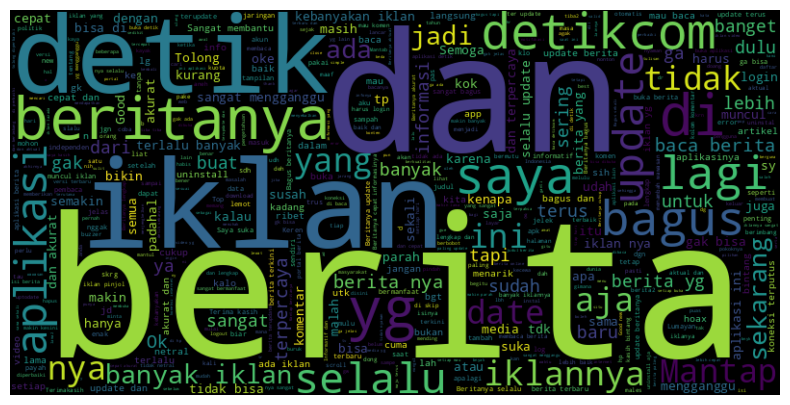

In [ ]:
import pandas as pd
import numpy as np
from PIL import Image
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator
import matplotlib.pyplot as plt

# Mengisi nilai NaN dengan string kosong ('')
df['Review Text'] = df['Review Text'].fillna('')

# Menggabungkan teks dari kolom 'content'
text = ' '.join(df['Review Text'].astype(str).tolist())

stopwords = set(STOPWORDS)
stopwords.update(['https', 'co', 'RT', '...', 'amp'])

wc = WordCloud(stopwords=stopwords, background_color="black", max_words=500, width=800, height=400)

wc.generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis("off")
plt.show()

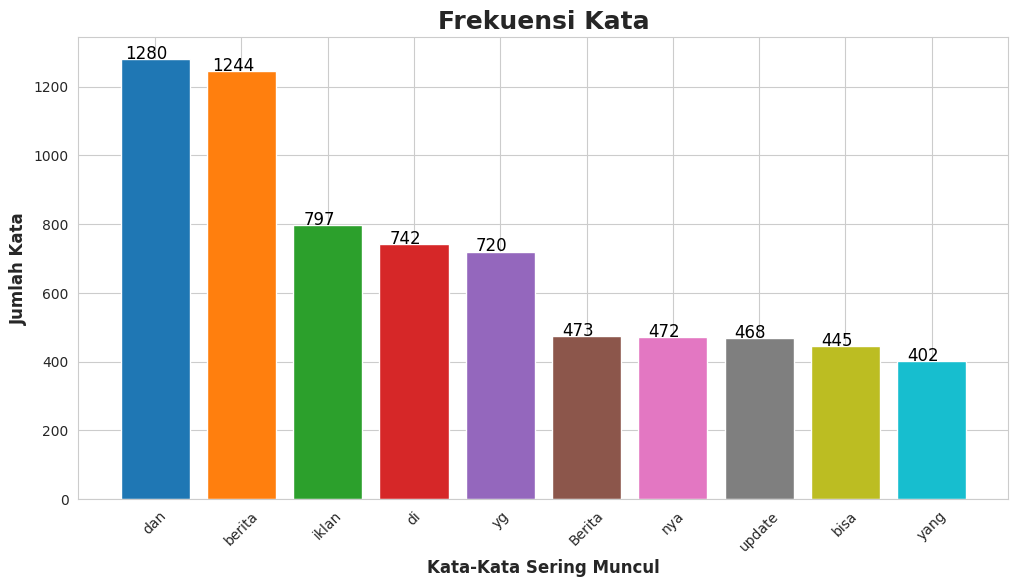

In [ ]:
import matplotlib.pyplot as plt
from collections import Counter

text = " ".join(df["Review Text"])

tokens = text.split()
word_counts = Counter(tokens)

top_words = word_counts.most_common(10)

word, count = zip(*top_words)

# Definisikan palet warna
colors = plt.cm.tab10(range(len(word)))

plt.figure(figsize=(12, 6))
bars = plt.bar(word, count, color=colors)
plt.xlabel("Kata-Kata Sering Muncul", fontsize=12, fontweight='bold')
plt.ylabel("Jumlah Kata", fontsize=12, fontweight='bold')
plt.title("Frekuensi Kata", fontsize=18, fontweight='bold')
plt.xticks(rotation=45)

# Menambahkan angka rata tengah di atas setiap bar
for bar, num in zip(bars, count):
    plt.text(bar.get_x() + bar.get_width() / 2 - 0.1, num + 1, str(num), fontsize=12, color='black', ha='center')


plt.show()

**PROSES CLEANING**

---



In [ ]:
import re
import string
import nltk

# Fungsi untuk menghapus URL
def remove_URL(tweet):
    if tweet is not None and isinstance(tweet, str):
        url = re.compile(r'https?://\S+|www\.\S+')
        return url.sub(r'', tweet)
    else:
        return tweet

# Fungsi untuk menghapus HTML
def remove_html(tweet):
    if tweet is not None and isinstance(tweet, str):
        html = re.compile(r'<.*?>')
        return html.sub(r'', tweet)
    else:
        return tweet

# Fungsi untuk menghapus emoji
def remove_emoji(tweet):
    if tweet is not None and isinstance(tweet, str):
        emoji_pattern = re.compile("["
            u"\U0001F600-\U0001F64F"  # emoticons
            u"\U0001F300-\U0001F5FF"  # symbols & pictographs
            u"\U0001F680-\U0001F6FF"  # transport & map symbols
            u"\U0001F700-\U0001F77F"  # alchemical symbols
            u"\U0001F780-\U0001F7FF"  # Geometric Shapes Extended
            u"\U0001F800-\U0001F8FF"  # Supplemental Arrows-C
            u"\U0001F900-\U0001F9FF"  # Supplemental Symbols and Pictographs
            u"\U0001FA00-\U0001FA6F"  # Chess Symbols
            u"\U0001FA70-\U0001FAFF"  # Symbols and Pictographs Extended-A
            u"\U0001F004-\U0001F0CF"  # Additional emoticons
            u"\U0001F1E0-\U0001F1FF"  # flags
                               "]+", flags=re.UNICODE)
        return emoji_pattern.sub(r'', tweet)
    else:
        return tweet

# Fungsi untuk menghapus simbol
def remove_symbols(tweet):
    if tweet is not None and isinstance(tweet, str):
        tweet = re.sub(r'[^a-zA-Z0-9\s]', '', tweet)
    return tweet

# Fungsi untuk menghapus angka
def remove_numbers(tweet):
    if tweet is not None and isinstance(tweet, str):
        tweet = re.sub(r'\d', '', tweet)
    return tweet

df['cleaning'] = df['Review Text'].apply(lambda x: remove_URL(x))
df['cleaning'] = df['cleaning'].apply(lambda x: remove_html(x))
df['cleaning'] = df['cleaning'].apply(lambda x: remove_emoji(x))
df['cleaning'] = df['cleaning'].apply(lambda x: remove_symbols(x))
df['cleaning'] = df['cleaning'].apply(lambda x: remove_numbers(x))

df.head(10)

,Date,Username,Rating,Review Text,cleaning
0,2026-04-03 05:08:50,Pengguna Google,3,detik sekarang iklannya ganggu banget... ga pe...,detik sekarang iklannya ganggu banget ga pence...
1,2026-03-31 09:50:30,Pengguna Google,5,terima kasih,terima kasih
2,2026-03-29 14:12:10,Pengguna Google,5,Ringan dan enak dibaca,Ringan dan enak dibaca
3,2026-03-28 11:18:10,Pengguna Google,5,dah lama jadi pembaca setia....mantap,dah lama jadi pembaca setiamantap
4,2026-03-24 08:14:31,Pengguna Google,1,sy mau hapus tdk bs,sy mau hapus tdk bs
5,2026-03-22 20:53:23,Pengguna Google,5,good news,good news
6,2026-03-19 16:26:41,Pengguna Google,1,Detik sekarang bukan lagi portal berita tapi p...,Detik sekarang bukan lagi portal berita tapi p...
7,2026-03-19 02:42:20,Pengguna Google,5,ok,ok
8,2026-03-18 23:46:03,Pengguna Google,5,saya sekarang lebih banyak membaca berita di d...,saya sekarang lebih banyak membaca berita di d...
9,2026-03-18 11:13:35,Pengguna Google,2,dibaca ga sih sama pihak detikcom ulasan2 disi...,dibaca ga sih sama pihak detikcom ulasan disin...


**PROSES CASE FOLDING**

---



In [ ]:
def case_folding(text):
    if isinstance(text, str):
        lowercase_text = text.lower()
        return lowercase_text
    else:
        return text

df['case_folding'] = df['cleaning'].apply(case_folding)
df.head(5)

,Date,Username,Rating,Review Text,cleaning,case_folding
0,2026-04-03 05:08:50,Pengguna Google,3,detik sekarang iklannya ganggu banget... ga pe...,detik sekarang iklannya ganggu banget ga pence...,detik sekarang iklannya ganggu banget ga pence...
1,2026-03-31 09:50:30,Pengguna Google,5,terima kasih,terima kasih,terima kasih
2,2026-03-29 14:12:10,Pengguna Google,5,Ringan dan enak dibaca,Ringan dan enak dibaca,ringan dan enak dibaca
3,2026-03-28 11:18:10,Pengguna Google,5,dah lama jadi pembaca setia....mantap,dah lama jadi pembaca setiamantap,dah lama jadi pembaca setiamantap
4,2026-03-24 08:14:31,Pengguna Google,1,sy mau hapus tdk bs,sy mau hapus tdk bs,sy mau hapus tdk bs


**Normalisasi Kata**

---



In [ ]:
import pandas as pd

# Fungsi penggantian kata tidak baku
def replace_taboo_words(text, kamus_tidak_baku):
    if isinstance(text, str):
        words = text.split()
        replaced_words = []
        kalimat_baku = []
        kata_diganti = []
        kata_tidak_baku_hash = []

        for word in words:
            if word in kamus_tidak_baku:
                baku_word = kamus_tidak_baku[word]
                if isinstance(baku_word, str) and all(char.isalpha() for char in baku_word):
                    replaced_words.append(baku_word)
                    kalimat_baku.append(baku_word)
                    kata_diganti.append(word)
                    kata_tidak_baku_hash.append(hash(word))
                # else:
                #     replaced_words.append('<karakter eksplisit>')
                #     kalimat_baku.append(word)
            else:
                replaced_words.append(word)
        replaced_text = ' '.join(replaced_words)
    else:
        replaced_text = ''
        kalimat_baku = []
        kata_diganti = []
        kata_tidak_baku_hash = []

    return replaced_text, kalimat_baku, kata_diganti, kata_tidak_baku_hash

In [ ]:
# Baca dataset
data =  pd.DataFrame(df[['Date','Username','Rating','Review Text','cleaning','case_folding']])
data.head(5)

,Date,Username,Rating,Review Text,cleaning,case_folding
0,2026-04-03 05:08:50,Pengguna Google,3,detik sekarang iklannya ganggu banget... ga pe...,detik sekarang iklannya ganggu banget ga pence...,detik sekarang iklannya ganggu banget ga pence...
1,2026-03-31 09:50:30,Pengguna Google,5,terima kasih,terima kasih,terima kasih
2,2026-03-29 14:12:10,Pengguna Google,5,Ringan dan enak dibaca,Ringan dan enak dibaca,ringan dan enak dibaca
3,2026-03-28 11:18:10,Pengguna Google,5,dah lama jadi pembaca setia....mantap,dah lama jadi pembaca setiamantap,dah lama jadi pembaca setiamantap
4,2026-03-24 08:14:31,Pengguna Google,1,sy mau hapus tdk bs,sy mau hapus tdk bs,sy mau hapus tdk bs


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("fornigulo/kamus-slag")

print("Path to dataset files:", path)

100%|██████████| 248k/248k [00:00<00:00, 44.0MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/fornigulo/kamus-slag/versions/1


In [ ]:
import shutil
import os

# Define the source directory (where the dataset is cached)
dataset_path = '/root/.cache/kagglehub/datasets/fornigulo/kamus-slag/versions/1'

# Define the destination path (where to move the files for visibility in the Colab file explorer)
destination_path = '/root/.cache/kagglehub/datasets/fornigulo/kamus-slag/versions/1'

# List the files to confirm the move
print("Files in the destination directory:", os.listdir(destination_path))

Files in the destination directory: ['kamuskatabaku.xlsx']


In [ ]:
import pandas as pd

# Path to the CSV file (update with the correct file name)
excel_file_path = '/root/.cache/kagglehub/datasets/fornigulo/kamus-slag/versions/1/kamuskatabaku.xlsx'  # Adjust the file name if necessary

# Load the CSV file into a DataFrame
df = pd.read_excel(excel_file_path)

# Display the first few rows of the dataset
print(df.head())

  tidak_baku kata_baku
0       woww       wow
1      aminn      amin
2        met   selamat
3     netaas   menetas
4    keberpa  keberapa


In [ ]:
# Baca kamus kata tidak baku
kamus_data = pd.read_excel('/root/.cache/kagglehub/datasets/fornigulo/kamus-slag/versions/1/kamuskatabaku.xlsx')
kamus_tidak_baku = dict(zip(kamus_data['tidak_baku'], kamus_data['kata_baku']))

In [ ]:
# Terapkan fungsi penggantian kata tidak baku
data['normalisasi'], data['Kata_Baku'], data['Kata_Tidak_Baku'], data['Kata_Tidak_Baku_Hash'] = zip(*data['case_folding'].apply(lambda x: replace_taboo_words(x, kamus_tidak_baku)))
# data.head(100)

df =  pd.DataFrame(data[['Date','Username','Rating','Review Text','cleaning','case_folding','normalisasi']])

df.head(20)

,Date,Username,Rating,Review Text,cleaning,case_folding,normalisasi
0,2026-04-03 05:08:50,Pengguna Google,3,detik sekarang iklannya ganggu banget... ga pe...,detik sekarang iklannya ganggu banget ga pence...,detik sekarang iklannya ganggu banget ga pence...,detik sekarang iklannya ganggu banget tidak pe...
1,2026-03-31 09:50:30,Pengguna Google,5,terima kasih,terima kasih,terima kasih,terima kasih
2,2026-03-29 14:12:10,Pengguna Google,5,Ringan dan enak dibaca,Ringan dan enak dibaca,ringan dan enak dibaca,ringan dan enak dibaca
3,2026-03-28 11:18:10,Pengguna Google,5,dah lama jadi pembaca setia....mantap,dah lama jadi pembaca setiamantap,dah lama jadi pembaca setiamantap,sudah lama jadi pembaca setiamantap
4,2026-03-24 08:14:31,Pengguna Google,1,sy mau hapus tdk bs,sy mau hapus tdk bs,sy mau hapus tdk bs,saya mau hapus tidak bisa
5,2026-03-22 20:53:23,Pengguna Google,5,good news,good news,good news,good news
6,2026-03-19 16:26:41,Pengguna Google,1,Detik sekarang bukan lagi portal berita tapi p...,Detik sekarang bukan lagi portal berita tapi p...,detik sekarang bukan lagi portal berita tapi p...,detik sekarang bukan lagi portal berita tapi p...
7,2026-03-19 02:42:20,Pengguna Google,5,ok,ok,ok,ok
8,2026-03-18 23:46:03,Pengguna Google,5,saya sekarang lebih banyak membaca berita di d...,saya sekarang lebih banyak membaca berita di d...,saya sekarang lebih banyak membaca berita di d...,saya sekarang lebih banyak membaca berita di d...
9,2026-03-18 11:13:35,Pengguna Google,2,dibaca ga sih sama pihak detikcom ulasan2 disi...,dibaca ga sih sama pihak detikcom ulasan disin...,dibaca ga sih sama pihak detikcom ulasan disin...,dibaca tidak sih sama pihak detikcom ulasan di...


**TOKENIZATION**

---



In [ ]:
def tokenize(text):
    tokens = text.split()
    return tokens

df['tokenize'] = df['normalisasi'].apply(tokenize)

df.head(5)

,Date,Username,Rating,Review Text,cleaning,case_folding,normalisasi,tokenize
0,2026-04-03 05:08:50,Pengguna Google,3,detik sekarang iklannya ganggu banget... ga pe...,detik sekarang iklannya ganggu banget ga pence...,detik sekarang iklannya ganggu banget ga pence...,detik sekarang iklannya ganggu banget tidak pe...,"[detik, sekarang, iklannya, ganggu, banget, ti..."
1,2026-03-31 09:50:30,Pengguna Google,5,terima kasih,terima kasih,terima kasih,terima kasih,"[terima, kasih]"
2,2026-03-29 14:12:10,Pengguna Google,5,Ringan dan enak dibaca,Ringan dan enak dibaca,ringan dan enak dibaca,ringan dan enak dibaca,"[ringan, dan, enak, dibaca]"
3,2026-03-28 11:18:10,Pengguna Google,5,dah lama jadi pembaca setia....mantap,dah lama jadi pembaca setiamantap,dah lama jadi pembaca setiamantap,sudah lama jadi pembaca setiamantap,"[sudah, lama, jadi, pembaca, setiamantap]"
4,2026-03-24 08:14:31,Pengguna Google,1,sy mau hapus tdk bs,sy mau hapus tdk bs,sy mau hapus tdk bs,saya mau hapus tidak bisa,"[saya, mau, hapus, tidak, bisa]"


**PROSES STOPWORD REMOVAL**

---



In [ ]:
from nltk.corpus import stopwords
nltk.download('stopwords')
stop_words = stopwords.words('indonesian')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
def remove_stopwords(text):
    return [word for word in text if word not in stop_words]

df['stopword removal'] = df['tokenize'].apply(lambda x: remove_stopwords(x))

df.head(5)

,Date,Username,Rating,Review Text,cleaning,case_folding,normalisasi,tokenize,stopword removal
0,2026-04-03 05:08:50,Pengguna Google,3,detik sekarang iklannya ganggu banget... ga pe...,detik sekarang iklannya ganggu banget ga pence...,detik sekarang iklannya ganggu banget ga pence...,detik sekarang iklannya ganggu banget tidak pe...,"[detik, sekarang, iklannya, ganggu, banget, ti...","[detik, iklannya, ganggu, banget, pencet, kada..."
1,2026-03-31 09:50:30,Pengguna Google,5,terima kasih,terima kasih,terima kasih,terima kasih,"[terima, kasih]","[terima, kasih]"
2,2026-03-29 14:12:10,Pengguna Google,5,Ringan dan enak dibaca,Ringan dan enak dibaca,ringan dan enak dibaca,ringan dan enak dibaca,"[ringan, dan, enak, dibaca]","[ringan, enak, dibaca]"
3,2026-03-28 11:18:10,Pengguna Google,5,dah lama jadi pembaca setia....mantap,dah lama jadi pembaca setiamantap,dah lama jadi pembaca setiamantap,sudah lama jadi pembaca setiamantap,"[sudah, lama, jadi, pembaca, setiamantap]","[pembaca, setiamantap]"
4,2026-03-24 08:14:31,Pengguna Google,1,sy mau hapus tdk bs,sy mau hapus tdk bs,sy mau hapus tdk bs,saya mau hapus tidak bisa,"[saya, mau, hapus, tidak, bisa]",[hapus]


**PROSES STEAMING DATA**

---



In [ ]:
!pip install Sastrawi

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from nltk.stem import PorterStemmer
from nltk.stem.snowball import SnowballStemmer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 6.5 MB/s eta 0:00:00


In [ ]:
factory = StemmerFactory()
stemmer = factory.create_stemmer()

def stem_text(text):
    return [stemmer.stem(word) for word in text]

df['steming_data'] = df['stopword removal'].apply(lambda x: ' '.join(stem_text(x)))
df.head(5)

,Date,Username,Rating,Review Text,cleaning,case_folding,normalisasi,tokenize,stopword removal,steming_data
0,2026-04-03 05:08:50,Pengguna Google,3,detik sekarang iklannya ganggu banget... ga pe...,detik sekarang iklannya ganggu banget ga pence...,detik sekarang iklannya ganggu banget ga pence...,detik sekarang iklannya ganggu banget tidak pe...,"[detik, sekarang, iklannya, ganggu, banget, ti...","[detik, iklannya, ganggu, banget, pencet, kada...",detik iklan ganggu banget pencet kadang muncul...
1,2026-03-31 09:50:30,Pengguna Google,5,terima kasih,terima kasih,terima kasih,terima kasih,"[terima, kasih]","[terima, kasih]",terima kasih
2,2026-03-29 14:12:10,Pengguna Google,5,Ringan dan enak dibaca,Ringan dan enak dibaca,ringan dan enak dibaca,ringan dan enak dibaca,"[ringan, dan, enak, dibaca]","[ringan, enak, dibaca]",ringan enak baca
3,2026-03-28 11:18:10,Pengguna Google,5,dah lama jadi pembaca setia....mantap,dah lama jadi pembaca setiamantap,dah lama jadi pembaca setiamantap,sudah lama jadi pembaca setiamantap,"[sudah, lama, jadi, pembaca, setiamantap]","[pembaca, setiamantap]",baca setiamantap
4,2026-03-24 08:14:31,Pengguna Google,1,sy mau hapus tdk bs,sy mau hapus tdk bs,sy mau hapus tdk bs,saya mau hapus tidak bisa,"[saya, mau, hapus, tidak, bisa]",[hapus],hapus


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7044 entries, 0 to 9998
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Date              7044 non-null   object
 1   Username          7044 non-null   object
 2   Rating            7044 non-null   int64 
 3   Review Text       7044 non-null   object
 4   cleaning          7044 non-null   object
 5   case_folding      7044 non-null   object
 6   normalisasi       7044 non-null   object
 7   tokenize          7044 non-null   object
 8   stopword removal  7044 non-null   object
 9   steming_data      7044 non-null   object
dtypes: int64(1), object(9)
memory usage: 863.4+ KB


**PROSES HAPUS DATA BERNILAI KOSONG (NAN)**

---



In [ ]:
data = df.dropna()
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7044 entries, 0 to 9998
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Date              7044 non-null   object
 1   Username          7044 non-null   object
 2   Rating            7044 non-null   int64 
 3   Review Text       7044 non-null   object
 4   cleaning          7044 non-null   object
 5   case_folding      7044 non-null   object
 6   normalisasi       7044 non-null   object
 7   tokenize          7044 non-null   object
 8   stopword removal  7044 non-null   object
 9   steming_data      7044 non-null   object
dtypes: int64(1), object(9)
memory usage: 863.4+ KB


**WORDCLOUD SETELAH PREPROCESSING**

---



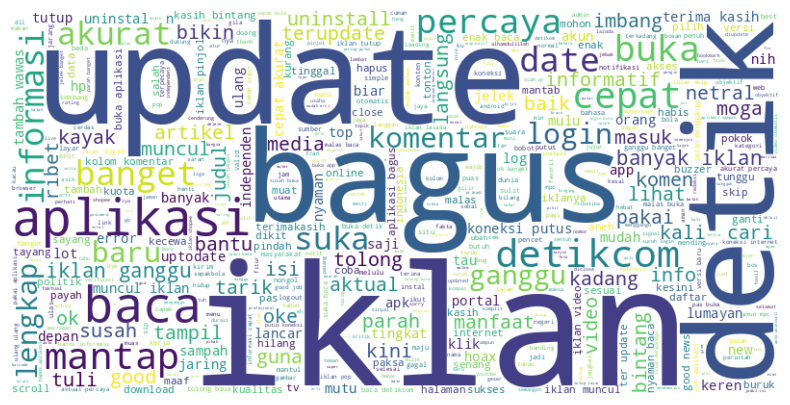

In [ ]:
import pandas as pd
import numpy as np
from PIL import Image
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator
import matplotlib.pyplot as plt

# Menggabungkan teks dari kolom 'steming_data'
text = ' '.join(df['steming_data'].astype(str).tolist())

stopwords = set(STOPWORDS)
stopwords.update(['https', 'co', 'RT', '...', 'amp','lu','deh','fyp', 'ya', 'gue', 'sih','berita'])

wc = WordCloud(stopwords=stopwords, background_color="white", max_words=500, width=800, height=400)

wc.generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis("off")
plt.show()

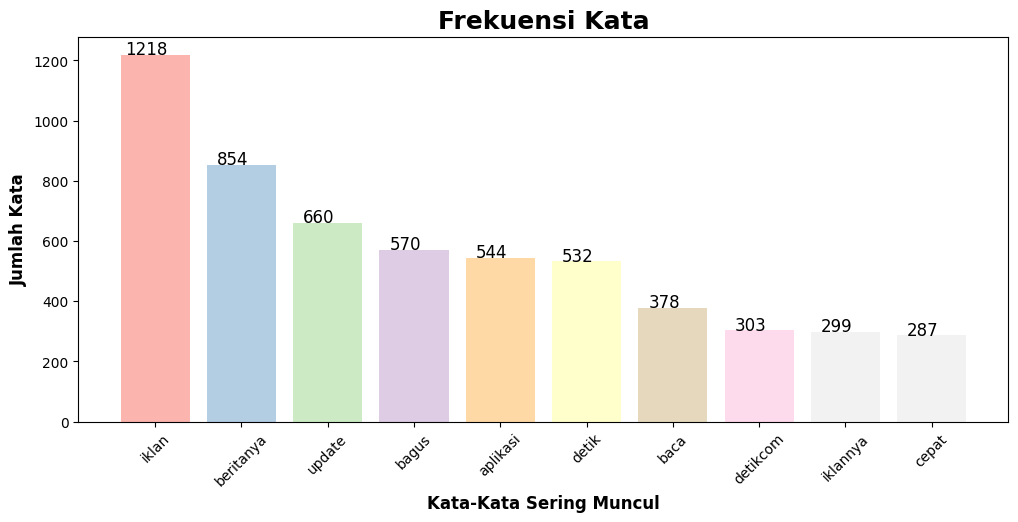

In [ ]:
import matplotlib.pyplot as plt
from collections import Counter
from wordcloud import STOPWORDS

# Convert the list of words in 'stopword removal' to strings before joining
text = ' '.join([' '.join(words) for words in df["stopword removal"]])

stopwords = set(STOPWORDS)
stopwords.update(['https', 'co', 'RT', '...', 'amp','lu','deh','fyp', 'ya', 'gue', 'sih','berita'])

tokens = [word for word in text.split() if word not in stopwords]
word_counts = Counter(tokens)

top_words = word_counts.most_common(10)
word, count = zip(*top_words)
# Menggunakan palet warna lebih soft
colors = plt.cm.Pastel1(range(len(word)))

# Membuat plot
plt.figure(figsize=(12, 5))
bars = plt.bar(word, count, color=colors)
plt.xlabel("Kata-Kata Sering Muncul", fontsize=12, fontweight='bold')
plt.ylabel("Jumlah Kata", fontsize=12, fontweight='bold')
plt.title("Frekuensi Kata", fontsize=18, fontweight='bold')
plt.xticks(rotation=45)

# Menambahkan angka rata tengah di atas setiap bar
for bar, num in zip(bars, count):
    plt.text(bar.get_x() + bar.get_width() / 2 - 0.1, num + 1, str(num), fontsize=12, color='black', ha='center')

# Menampilkan plot
plt.show()

In [ ]:
df.to_csv('Hasil_Preprocessing_Data_Detikcom.csv',encoding='utf8', index=False);

# ***PELEBALAN DATA METODE LAXICON BASED***

In [ ]:
import pandas as pd

data = pd.read_csv("Hasil_Preprocessing_Data_Detikcom.csv")
data.info()
data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7044 entries, 0 to 7043
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Date              7044 non-null   object
 1   Username          7044 non-null   object
 2   Rating            7044 non-null   int64 
 3   Review Text       7044 non-null   object
 4   cleaning          6981 non-null   object
 5   case_folding      6981 non-null   object
 6   normalisasi       6976 non-null   object
 7   tokenize          7044 non-null   object
 8   stopword removal  7044 non-null   object
 9   steming_data      6919 non-null   object
dtypes: int64(1), object(9)
memory usage: 550.4+ KB


,Date,Username,Rating,Review Text,cleaning,case_folding,normalisasi,tokenize,stopword removal,steming_data
0,2026-04-03 05:08:50,Pengguna Google,3,detik sekarang iklannya ganggu banget... ga pe...,detik sekarang iklannya ganggu banget ga pence...,detik sekarang iklannya ganggu banget ga pence...,detik sekarang iklannya ganggu banget tidak pe...,"['detik', 'sekarang', 'iklannya', 'ganggu', 'b...","['detik', 'iklannya', 'ganggu', 'banget', 'pen...",detik iklan ganggu banget pencet kadang muncul...
1,2026-03-31 09:50:30,Pengguna Google,5,terima kasih,terima kasih,terima kasih,terima kasih,"['terima', 'kasih']","['terima', 'kasih']",terima kasih
2,2026-03-29 14:12:10,Pengguna Google,5,Ringan dan enak dibaca,Ringan dan enak dibaca,ringan dan enak dibaca,ringan dan enak dibaca,"['ringan', 'dan', 'enak', 'dibaca']","['ringan', 'enak', 'dibaca']",ringan enak baca
3,2026-03-28 11:18:10,Pengguna Google,5,dah lama jadi pembaca setia....mantap,dah lama jadi pembaca setiamantap,dah lama jadi pembaca setiamantap,sudah lama jadi pembaca setiamantap,"['sudah', 'lama', 'jadi', 'pembaca', 'setiaman...","['pembaca', 'setiamantap']",baca setiamantap
4,2026-03-24 08:14:31,Pengguna Google,1,sy mau hapus tdk bs,sy mau hapus tdk bs,sy mau hapus tdk bs,saya mau hapus tidak bisa,"['saya', 'mau', 'hapus', 'tidak', 'bisa']",['hapus'],hapus


In [ ]:
data = data.dropna()
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6919 entries, 0 to 7043
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Date              6919 non-null   object
 1   Username          6919 non-null   object
 2   Rating            6919 non-null   int64 
 3   Review Text       6919 non-null   object
 4   cleaning          6919 non-null   object
 5   case_folding      6919 non-null   object
 6   normalisasi       6919 non-null   object
 7   tokenize          6919 non-null   object
 8   stopword removal  6919 non-null   object
 9   steming_data      6919 non-null   object
dtypes: int64(1), object(9)
memory usage: 594.6+ KB


In [ ]:
data = pd.DataFrame(data[['steming_data']])
data.head(5)

,steming_data
0,detik iklan ganggu banget pencet kadang muncul...
1,terima kasih
2,ringan enak baca
3,baca setiamantap
4,hapus


In [ ]:
import pandas as pd
import requests

# Unduh kamus leksikon positif dan negatif dari GitHub
positive_url = "https://raw.githubusercontent.com/fajri91/InSet/master/positive.tsv"
negative_url = "https://raw.githubusercontent.com/fajri91/InSet/master/negative.tsv"

positive_lexicon = set(pd.read_csv(positive_url, sep="\t", header=None)[0])
negative_lexicon = set(pd.read_csv(negative_url, sep="\t", header=None)[0])

# Fungsi untuk menentukan sentimen dan menghitung skornya
def determine_sentiment(text):
    if isinstance(text, str):
        positive_count = sum(1 for word in text.split() if word in positive_lexicon)
        negative_count = sum(1 for word in text.split() if word in negative_lexicon)
        sentiment_score = positive_count - negative_count
        if sentiment_score > 0:
            sentiment = "Positif"
        elif sentiment_score < 0:
            sentiment = "Negatif"
        else:
            sentiment = "Netral"
        return sentiment_score, sentiment
    return 0, "Netral"


# Tentukan sentimen dan skor untuk setiap ulasan
data[['Score', 'Sentiment']] = data['steming_data'].apply(lambda x: pd.Series(determine_sentiment(x)))

# Tampilkan hasilnya
data.head(20)


,steming_data,Score,Sentiment
0,detik iklan ganggu banget pencet kadang muncul...,2,Positif
1,terima kasih,1,Positif
2,ringan enak baca,0,Netral
3,baca setiamantap,0,Netral
4,hapus,-1,Negatif
5,good news,1,Positif
6,detik portal berita portal iklan kali ganggu b...,-4,Negatif
7,ok,1,Positif
8,baca berita detik jarang buka media sosial,0,Netral
9,baca sih detikcom ulas komplen iklan seliwer t...,-3,Negatif


/tmp/ipykernel_2245/1910355637.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=sentiment_count.index, y=sentiment_count.values, palette='pastel')


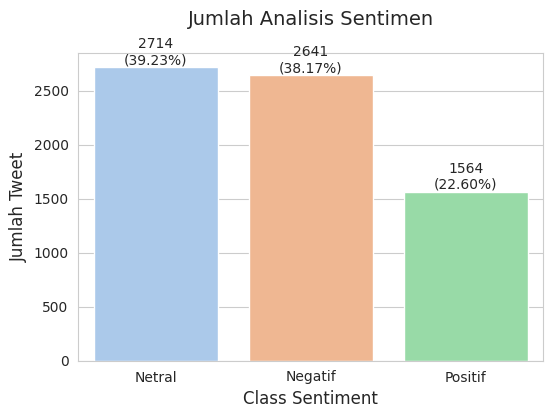

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sentiment_count = data['Sentiment'].value_counts()
sns.set_style('whitegrid')

fig, ax = plt.subplots(figsize=(6, 4))
ax = sns.barplot(x=sentiment_count.index, y=sentiment_count.values, palette='pastel')
plt.title('Jumlah Analisis Sentimen', fontsize=14, pad=20)
plt.xlabel('Class Sentiment', fontsize=12)
plt.ylabel('Jumlah Tweet', fontsize=12)

total = len(data['Sentiment'])

for i, count in enumerate(sentiment_count.values):
    percentage = f'{100 * count / total:.2f}%'
    ax.text(i, count + 0.10, f'{count}\n({percentage})', ha='center', va='bottom')

plt.show()

In [ ]:
data.to_csv('Hasil_Labelling_Data_Detikcom.csv',encoding='utf8', index=False)

**WORDCLOUD**

---



In [ ]:
import pandas as pd

data = pd.read_csv("Hasil_Labelling_Data_Detikcom.csv")
data.head(5)

,steming_data,Score,Sentiment
0,detik iklan ganggu banget pencet kadang muncul...,2,Positif
1,terima kasih,1,Positif
2,ringan enak baca,0,Netral
3,baca setiamantap,0,Netral
4,hapus,-1,Negatif


In [ ]:
import pandas as pd
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Pisahkan dataset berdasarkan sentimen
sentimen_Neutral = data[data['Sentiment'] == 'Netral']['steming_data'].str.cat(sep=' ')
sentimen_Negative = data[data['Sentiment'] == 'Negatif']['steming_data'].str.cat(sep=' ')
sentimen_Positive = data[data['Sentiment'] == 'Positif']['steming_data'].str.cat(sep=' ')

In [ ]:
# Fungsi untuk membuat dan menampilkan WordCloud
def create_wordcloud(text, title):
    wordcloud = WordCloud(width=800, height=400, random_state=42, max_font_size=100, background_color='white').generate(text)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title)
    plt.show()

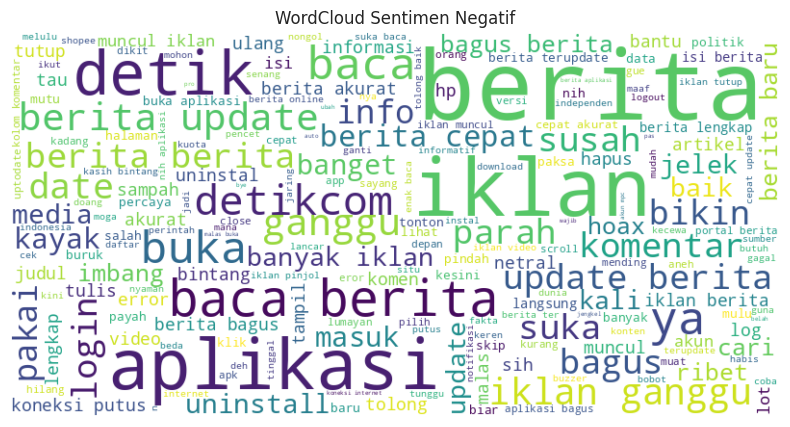

In [ ]:
# Membuat WordCloud untuk sentimen Negatif
create_wordcloud(sentimen_Negative, 'WordCloud Sentimen Negatif')

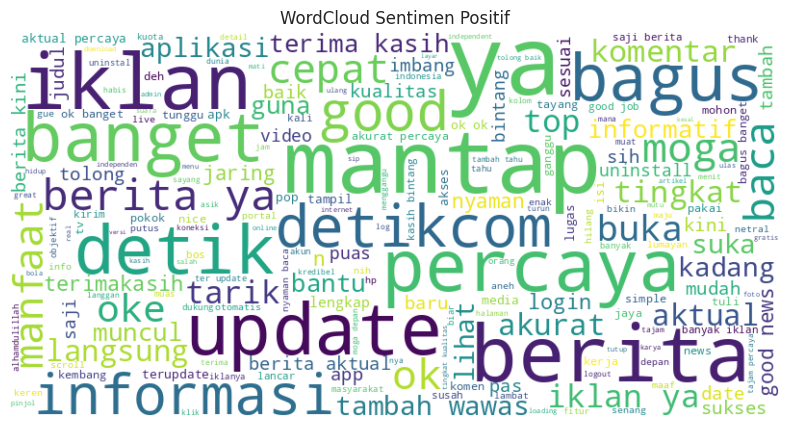

In [ ]:
# Membuat WordCloud untuk sentimen Positif
create_wordcloud(sentimen_Positive, 'WordCloud Sentimen Positif')

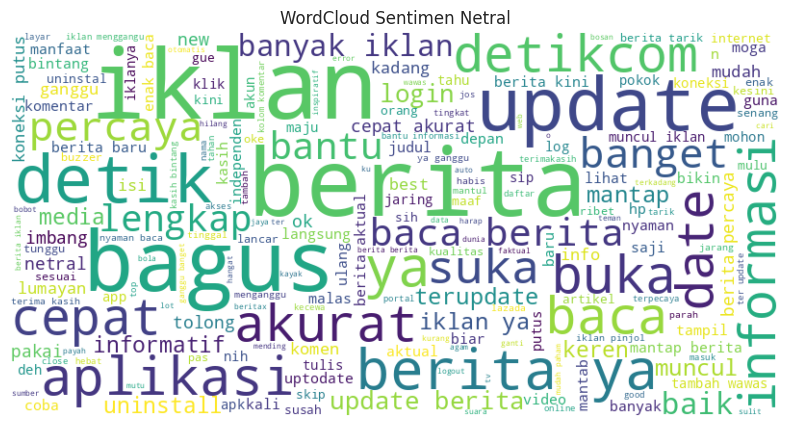

In [ ]:
# Membuat WordCloud untuk sentimen Netral
create_wordcloud(sentimen_Neutral, 'WordCloud Sentimen Netral')

# ***SVM (Support Vector Machine), KNN (K-Nearest Neighbor), Naive Bayes, Random Forest, Decision Tree, Neural Network***

In [ ]:
import pandas as pd

file_path = 'Hasil_Labelling_Data_Detikcom.csv'
data = pd.read_csv(file_path)

data.info()
data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6919 entries, 0 to 6918
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   steming_data  6919 non-null   object
 1   Score         6919 non-null   int64 
 2   Sentiment     6919 non-null   object
dtypes: int64(1), object(2)
memory usage: 162.3+ KB


,steming_data,Score,Sentiment
0,detik iklan ganggu banget pencet kadang muncul...,2,Positif
1,terima kasih,1,Positif
2,ringan enak baca,0,Netral
3,baca setiamantap,0,Netral
4,hapus,-1,Negatif


In [ ]:

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer

cleaned_data = data.dropna(subset=['steming_data'])

X = cleaned_data['steming_data']
y = cleaned_data['Sentiment']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Jumlah data latih:", len(X_train))
print("Jumlah data uji:", len(X_test))
print('===========================')

vectorizer = CountVectorizer()
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

X_train_vec.shape, X_test_vec.shape

Jumlah data latih: 5535
Jumlah data uji: 1384


((5535, 4665), (1384, 4665))

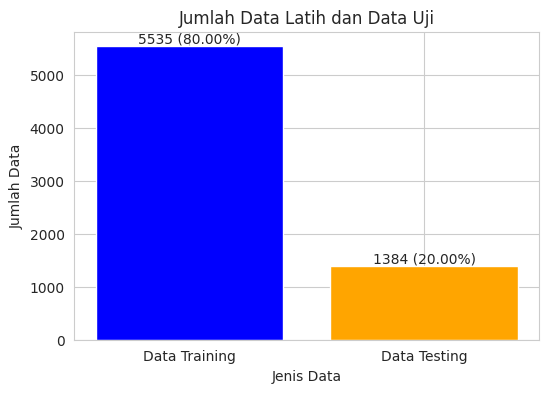

In [ ]:
import matplotlib.pyplot as plt


train_size = len(X_train)
test_size = len(X_test)

plt.figure(figsize=(6, 4))
bars = plt.bar(['Data Training', 'Data Testing'], [train_size, test_size], color=['blue', 'orange'])

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 1, f'{height} ({height / (train_size + test_size) * 100:.2f}%)',
             ha='center', va='bottom')

plt.title('Jumlah Data Latih dan Data Uji')
plt.xlabel('Jenis Data')
plt.ylabel('Jumlah Data')
plt.show()


In [ ]:
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.neural_network import MLPClassifier
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Embedding, SpatialDropout1D
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier

# Initialize models
models = {
    "SVM": SVC(kernel='linear', random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Naive Bayes": MultinomialNB(),
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=100),
    "Decision Trees": DecisionTreeClassifier(random_state=42),
    "Neural Network": MLPClassifier(random_state=42, hidden_layer_sizes=(100,), max_iter=500),
}

# Train models
results = {}
for model_name, model in models.items():
    model.fit(X_train_vec, y_train)
    y_pred = model.predict(X_test_vec)
    results[model_name] = {
        "accuracy": accuracy_score(y_test, y_pred),
        "classification_report": classification_report(y_test, y_pred, output_dict=True),
        "confusion_matrix": confusion_matrix(y_test, y_pred)
    }


Confusion Matrix for SVM:


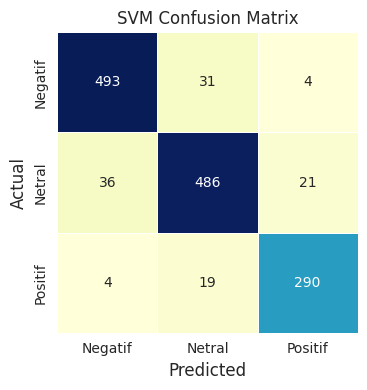


Confusion Matrix for KNN:


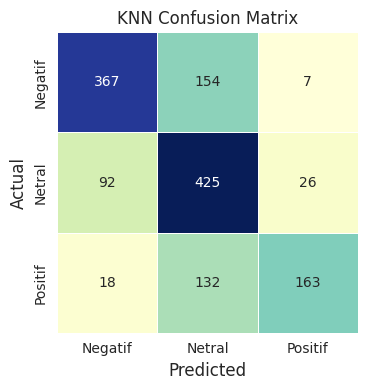


Confusion Matrix for Naive Bayes:


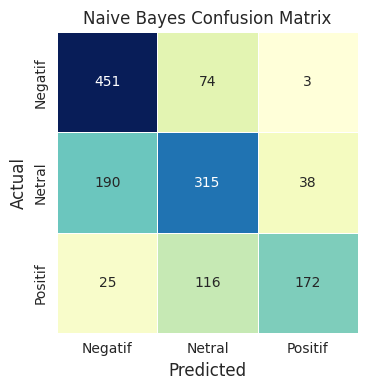


Confusion Matrix for Random Forest:


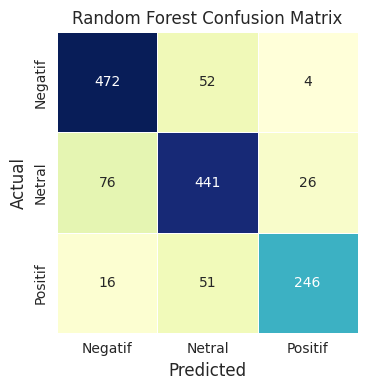


Confusion Matrix for Decision Trees:


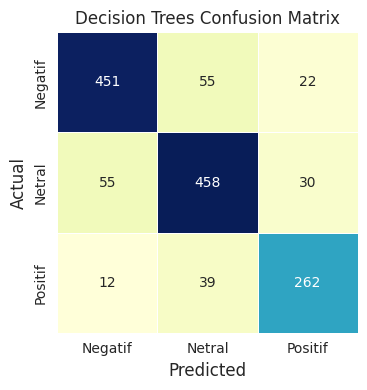


Confusion Matrix for Neural Network:


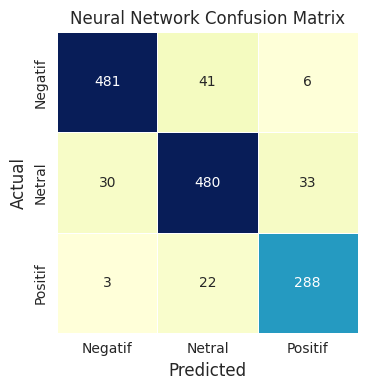

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

for model_name, result in results.items():
    fig, ax = plt.subplots(figsize=(4, 4))
    sns.heatmap(
        result["confusion_matrix"],
        annot=True,
        fmt='d',
        cmap="YlGnBu",
        cbar=False,
        xticklabels=['Negatif', 'Netral', 'Positif'],
        yticklabels=['Negatif', 'Netral', 'Positif'],
        ax=ax,
        square=True,
        linewidths=0.5
    )
    print(f"\nConfusion Matrix for {model_name}:")
    ax.set_title(f"{model_name} Confusion Matrix", fontsize=12)
    ax.set_xlabel("Predicted", fontsize=12)
    ax.set_ylabel("Actual", fontsize=12)


    plt.tight_layout()
    plt.show()


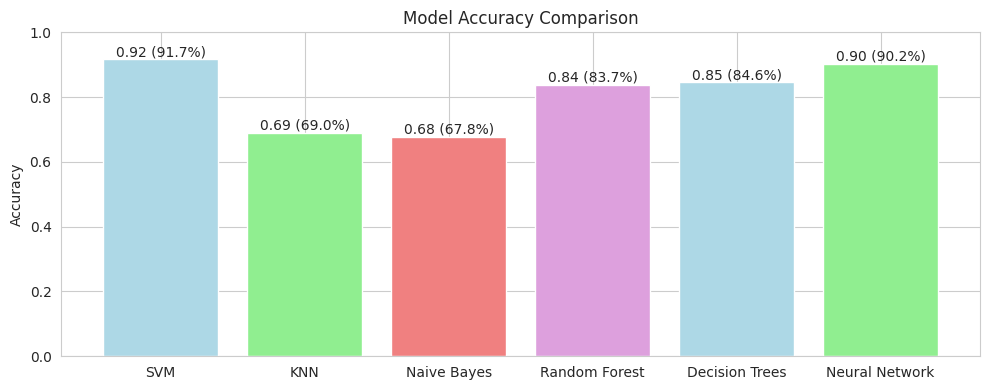

In [ ]:
import matplotlib.pyplot as plt

accuracies = {model: result['accuracy'] for model, result in results.items()}

plt.figure(figsize=(10, 4))
bars = plt.bar(list(accuracies.keys()), list(accuracies.values()), color=['lightblue', 'lightgreen', 'lightcoral', 'plum'])

for bar in bars:
    accuracy = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        accuracy,
        f'{accuracy:.2f} ({accuracy * 100:.1f}%)',
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


In [ ]:
from IPython.display import display

for model_name, result in results.items():
    print(f"\nClassification Report for {model_name}:")

    report_df = pd.DataFrame(result['classification_report']).transpose()

    styled_df = report_df.style.background_gradient(cmap="coolwarm")
    styled_df = styled_df.format(precision=3)
    display(styled_df)


Classification Report for SVM:


,precision,recall,f1-score,support
Negatif,0.925,0.934,0.929,528.000
Netral,0.907,0.895,0.901,543.000
Positif,0.921,0.927,0.924,313.000
accuracy,0.917,0.917,0.917,0.917
macro avg,0.917,0.918,0.918,1384.000
weighted avg,0.917,0.917,0.917,1384.000



Classification Report for KNN:


,precision,recall,f1-score,support
Negatif,0.769,0.695,0.730,528.000
Netral,0.598,0.783,0.678,543.000
Positif,0.832,0.521,0.640,313.000
accuracy,0.690,0.690,0.690,0.690
macro avg,0.733,0.666,0.683,1384.000
weighted avg,0.716,0.690,0.689,1384.000



Classification Report for Naive Bayes:


...

,precision,recall,f1-score,support
Negatif,0.837,0.894,0.864,528.000
Netral,0.811,0.812,0.811,543.000
Positif,0.891,0.786,0.835,313.000
accuracy,0.837,0.837,0.837,0.837
macro avg,0.846,0.831,0.837,1384.000
weighted avg,0.839,0.837,0.837,1384.000



Classification Report for Decision Trees:


,precision,recall,f1-score,support
Negatif,0.871,0.854,0.862,528.000
Netral,0.830,0.843,0.837,543.000
Positif,0.834,0.837,0.836,313.000
accuracy,0.846,0.846,0.846,0.846
macro avg,0.845,0.845,0.845,1384.000
weighted avg,0.846,0.846,0.846,1384.000



Classification Report for Neural Network:


,precision,recall,f1-score,support
Negatif,0.936,0.911,0.923,528.000
Netral,0.884,0.884,0.884,543.000
Positif,0.881,0.920,0.900,313.000
accuracy,0.902,0.902,0.902,0.902
macro avg,0.900,0.905,0.902,1384.000
weighted avg,0.903,0.902,0.903,1384.000


# ***DATA SCRAPPING CNN INDONESIA***

In [ ]:
from google_play_scraper import reviews, Sort

# Update the app_id to CNN Indonesia - Berita Terkini
app_id = 'com.cnn.indonesia'

def get_reviews(app_id, lang='id', count=10000, sort=Sort.NEWEST, filter_score_with=None, filter_device_with=None, continuation_token=None):
    try:
        result, continuation_token = reviews(
            app_id,
            lang=lang,
            country='id',  # Specify Indonesia
            sort=sort,      # Sort by newest reviews
            count=count,    # Number of reviews to fetch
            filter_score_with=filter_score_with,
            filter_device_with=filter_device_with,
            continuation_token=continuation_token
        )

        return result, continuation_token
    except Exception as e:
        print("Error:", e)
        return None, None

# Get the reviews for CNN Indonesia - Berita Terkini
reviews, continuation_token = get_reviews(app_id)

if reviews is not None:
    print("Jumlah ulasan:", len(reviews))  # Total number of reviews
    if len(reviews) > 0:
        print("Contoh ulasan:")
        print(reviews[0])  # Display the first review as an example
else:
    print("Tidak dapat mengambil ulasan.")

Jumlah ulasan: 10000
Contoh ulasan:
{'reviewId': '93ea49c7-f65a-4c48-8600-a9d20cca5b18', 'userName': 'Pengguna Google', 'userImage': 'https://play-lh.googleusercontent.com/EGemoI2NTXmTsBVtJqk8jxF9rh8ApRWfsIMQSt2uE4OcpQqbFu7f7NbTK05lx80nuSijCz7sc3a277R67g', 'content': 'berita nya akurat', 'score': 5, 'thumbsUpCount': 0, 'reviewCreatedVersion': '2.42.1', 'at': datetime.datetime(2026, 4, 6, 11, 53, 22), 'replyContent': None, 'repliedAt': None, 'appVersion': '2.42.1'}


In [ ]:
import csv

def export_to_csv(reviews, file_name='hasil_scraper_ulasan_app_cnn_indonesia.csv'):
    if reviews:
        fieldnames = ['Review ID', 'Username', 'Rating', 'Review Text', 'Date']

        with open(file_name, mode='w', newline='', encoding='utf-8') as csv_file:
            writer = csv.DictWriter(csv_file, fieldnames=fieldnames)
            writer.writeheader()

            for review in reviews:
                writer.writerow({
                    'Review ID': review['reviewId'],
                    'Username': review['userName'],
                    'Rating': review['score'],
                    'Review Text': review['content'],
                    'Date': review['at']
                })

        print(f"Data berhasil diekspor ke '{file_name}'")
    else:
        print("Tidak ada data ulasan untuk diekspor.")

export_to_csv(reviews)


Data berhasil diekspor ke 'hasil_scraper_ulasan_app_cnn_indonesia.csv'


# ***PREPROCESSING DATA***

In [ ]:
import pandas as pd

data = pd.read_csv("hasil_scraper_ulasan_app_cnn_indonesia.csv")
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Review ID    10000 non-null  object
 1   Username     10000 non-null  object
 2   Rating       10000 non-null  int64 
 3   Review Text  9999 non-null   object
 4   Date         10000 non-null  object
dtypes: int64(1), object(4)
memory usage: 390.8+ KB


In [ ]:
data.head(20)

,Review ID,Username,Rating,Review Text,Date
0,93ea49c7-f65a-4c48-8600-a9d20cca5b18,Pengguna Google,5,berita nya akurat,2026-04-06 11:53:22
1,48fdc432-220d-4b70-8d7e-dcdda9ae35f7,Pengguna Google,4,"beritanya cukup uptodate, tidak ketinggalan wa...",2026-04-04 06:39:40
2,d11b4fc0-41ea-4434-bf4d-c001421db15f,Pengguna Google,3,ulasan beritanya utk berita luar negeri terlih...,2026-03-31 06:28:58
3,f9c1bef8-76bd-43ee-94af-ad921290a8cb,Pengguna Google,5,Good,2026-03-31 03:54:03
4,3bdb887d-8c16-4811-82a0-67b15c8ee150,Pengguna Google,3,lemottt bangettt,2026-03-28 05:46:03
5,db089a0b-4685-47ba-a53e-1a5472d464cb,Pengguna Google,1,"Beritanya gak netral, gak sesuai fakta, kalo o...",2026-03-25 23:25:12
6,f0a6467c-4e31-4e1f-9385-5c74022de86b,Pengguna Google,5,terdepan,2026-03-24 23:18:08
7,b8f63154-3feb-424c-a6e5-9fc4f729a576,Pengguna Google,5,bagus,2026-03-22 17:49:02
8,633a3e09-38c9-4c4f-8cc3-08a629560568,Pengguna Google,5,good news,2026-03-20 00:01:54
9,6dc72bcd-fbed-4779-9e37-d93efd889a78,Pengguna Google,5,berita terbaru,2026-03-18 20:15:34


In [ ]:
import pandas as pd

data = pd.read_csv("hasil_scraper_ulasan_app_cnn_indonesia.csv")
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Review ID    10000 non-null  object
 1   Username     10000 non-null  object
 2   Rating       10000 non-null  int64 
 3   Review Text  9999 non-null   object
 4   Date         10000 non-null  object
dtypes: int64(1), object(4)
memory usage: 390.8+ KB


In [ ]:
data.head(5)

,Review ID,Username,Rating,Review Text,Date
0,93ea49c7-f65a-4c48-8600-a9d20cca5b18,Pengguna Google,5,berita nya akurat,2026-04-06 11:53:22
1,48fdc432-220d-4b70-8d7e-dcdda9ae35f7,Pengguna Google,4,"beritanya cukup uptodate, tidak ketinggalan wa...",2026-04-04 06:39:40
2,d11b4fc0-41ea-4434-bf4d-c001421db15f,Pengguna Google,3,ulasan beritanya utk berita luar negeri terlih...,2026-03-31 06:28:58
3,f9c1bef8-76bd-43ee-94af-ad921290a8cb,Pengguna Google,5,Good,2026-03-31 03:54:03
4,3bdb887d-8c16-4811-82a0-67b15c8ee150,Pengguna Google,3,lemottt bangettt,2026-03-28 05:46:03


In [ ]:
df  = pd.DataFrame(data[['Date','Username','Rating','Review Text']])
df.head(5)

,Date,Username,Rating,Review Text
0,2026-04-06 11:53:22,Pengguna Google,5,berita nya akurat
1,2026-04-04 06:39:40,Pengguna Google,4,"beritanya cukup uptodate, tidak ketinggalan wa..."
2,2026-03-31 06:28:58,Pengguna Google,3,ulasan beritanya utk berita luar negeri terlih...
3,2026-03-31 03:54:03,Pengguna Google,5,Good
4,2026-03-28 05:46:03,Pengguna Google,3,lemottt bangettt


**PROSES HAPUS DATA DUPLIKAT**

---



In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Date         10000 non-null  object
 1   Username     10000 non-null  object
 2   Rating       10000 non-null  int64 
 3   Review Text  9999 non-null   object
dtypes: int64(1), object(3)
memory usage: 312.6+ KB


In [ ]:
df.describe()

,Rating
count,10000.000000
mean,4.077500
std,1.421582
min,1.000000
25%,4.000000
50%,5.000000
75%,5.000000
max,5.000000


In [ ]:
df.drop_duplicates(subset ="Review Text", keep = 'first', inplace = True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7290 entries, 0 to 9999
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Date         7290 non-null   object
 1   Username     7290 non-null   object
 2   Rating       7290 non-null   int64 
 3   Review Text  7289 non-null   object
dtypes: int64(1), object(3)
memory usage: 284.8+ KB


**WORDCLOUD SEBELUM PREPROCESSING**

---



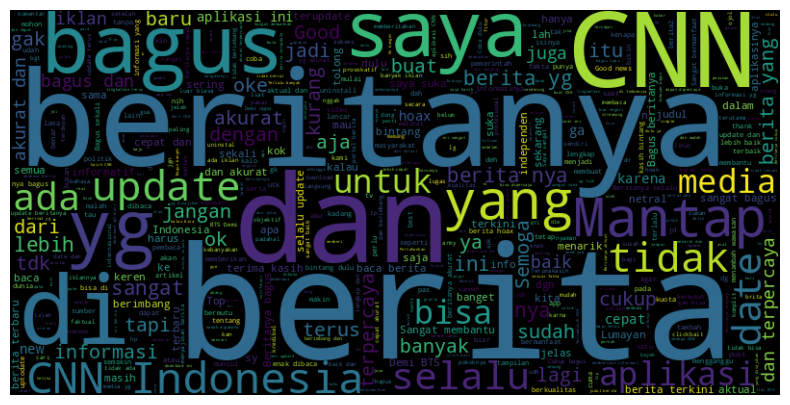

In [ ]:
import pandas as pd
import numpy as np
from PIL import Image
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator
import matplotlib.pyplot as plt

# Mengisi nilai NaN dengan string kosong ('')
df['Review Text'] = df['Review Text'].fillna('')

# Menggabungkan teks dari kolom 'content'
text = ' '.join(df['Review Text'].astype(str).tolist())

stopwords = set(STOPWORDS)
stopwords.update(['https', 'co', 'RT', '...', 'amp'])

wc = WordCloud(stopwords=stopwords, background_color="black", max_words=500, width=800, height=400)

wc.generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis("off")
plt.show()

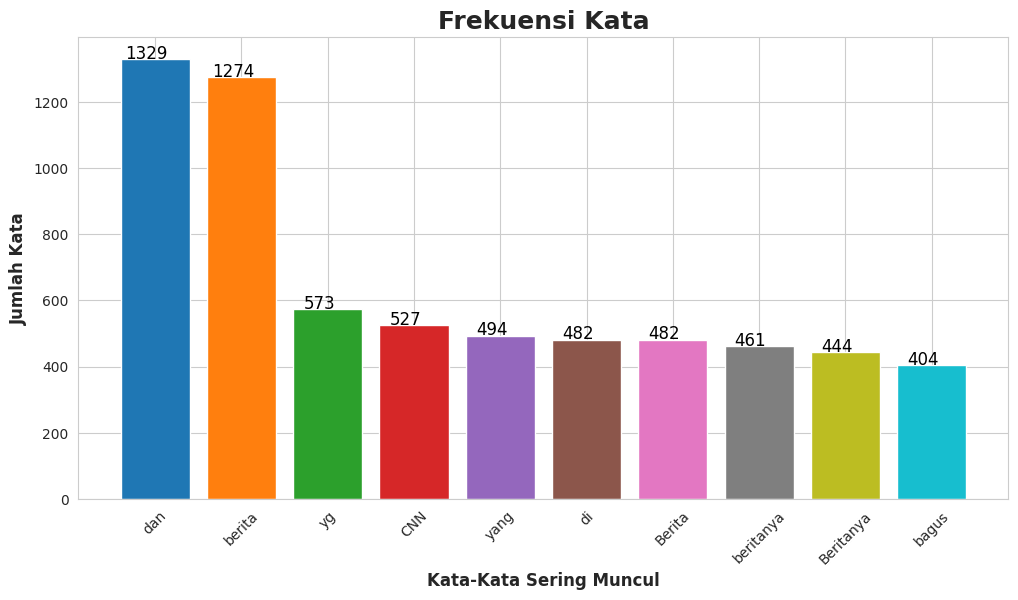

In [ ]:
import matplotlib.pyplot as plt
from collections import Counter

text = " ".join(df["Review Text"])

tokens = text.split()
word_counts = Counter(tokens)

top_words = word_counts.most_common(10)

word, count = zip(*top_words)

# Definisikan palet warna
colors = plt.cm.tab10(range(len(word)))

plt.figure(figsize=(12, 6))
bars = plt.bar(word, count, color=colors)
plt.xlabel("Kata-Kata Sering Muncul", fontsize=12, fontweight='bold')
plt.ylabel("Jumlah Kata", fontsize=12, fontweight='bold')
plt.title("Frekuensi Kata", fontsize=18, fontweight='bold')
plt.xticks(rotation=45)

# Menambahkan angka rata tengah di atas setiap bar
for bar, num in zip(bars, count):
    plt.text(bar.get_x() + bar.get_width() / 2 - 0.1, num + 1, str(num), fontsize=12, color='black', ha='center')


plt.show()

**PROSES CLEANING**

---



In [ ]:
import re
import string
import nltk

# Fungsi untuk menghapus URL
def remove_URL(tweet):
    if tweet is not None and isinstance(tweet, str):
        url = re.compile(r'https?://\S+|www\.\S+')
        return url.sub(r'', tweet)
    else:
        return tweet

# Fungsi untuk menghapus HTML
def remove_html(tweet):
    if tweet is not None and isinstance(tweet, str):
        html = re.compile(r'<.*?>')
        return html.sub(r'', tweet)
    else:
        return tweet

# Fungsi untuk menghapus emoji
def remove_emoji(tweet):
    if tweet is not None and isinstance(tweet, str):
        emoji_pattern = re.compile("["
            u"\U0001F600-\U0001F64F"  # emoticons
            u"\U0001F300-\U0001F5FF"  # symbols & pictographs
            u"\U0001F680-\U0001F6FF"  # transport & map symbols
            u"\U0001F700-\U0001F77F"  # alchemical symbols
            u"\U0001F780-\U0001F7FF"  # Geometric Shapes Extended
            u"\U0001F800-\U0001F8FF"  # Supplemental Arrows-C
            u"\U0001F900-\U0001F9FF"  # Supplemental Symbols and Pictographs
            u"\U0001FA00-\U0001FA6F"  # Chess Symbols
            u"\U0001FA70-\U0001FAFF"  # Symbols and Pictographs Extended-A
            u"\U0001F004-\U0001F0CF"  # Additional emoticons
            u"\U0001F1E0-\U0001F1FF"  # flags
                               "]+", flags=re.UNICODE)
        return emoji_pattern.sub(r'', tweet)
    else:
        return tweet

# Fungsi untuk menghapus simbol
def remove_symbols(tweet):
    if tweet is not None and isinstance(tweet, str):
        tweet = re.sub(r'[^a-zA-Z0-9\s]', '', tweet)
    return tweet

# Fungsi untuk menghapus angka
def remove_numbers(tweet):
    if tweet is not None and isinstance(tweet, str):
        tweet = re.sub(r'\d', '', tweet)
    return tweet

df['cleaning'] = df['Review Text'].apply(lambda x: remove_URL(x))
df['cleaning'] = df['cleaning'].apply(lambda x: remove_html(x))
df['cleaning'] = df['cleaning'].apply(lambda x: remove_emoji(x))
df['cleaning'] = df['cleaning'].apply(lambda x: remove_symbols(x))
df['cleaning'] = df['cleaning'].apply(lambda x: remove_numbers(x))

df.head(10)

,Date,Username,Rating,Review Text,cleaning
0,2026-04-06 11:53:22,Pengguna Google,5,berita nya akurat,berita nya akurat
1,2026-04-04 06:39:40,Pengguna Google,4,"beritanya cukup uptodate, tidak ketinggalan wa...",beritanya cukup uptodate tidak ketinggalan wak...
2,2026-03-31 06:28:58,Pengguna Google,3,ulasan beritanya utk berita luar negeri terlih...,ulasan beritanya utk berita luar negeri terlih...
3,2026-03-31 03:54:03,Pengguna Google,5,Good,Good
4,2026-03-28 05:46:03,Pengguna Google,3,lemottt bangettt,lemottt bangettt
5,2026-03-25 23:25:12,Pengguna Google,1,"Beritanya gak netral, gak sesuai fakta, kalo o...",Beritanya gak netral gak sesuai fakta kalo obj...
6,2026-03-24 23:18:08,Pengguna Google,5,terdepan,terdepan
7,2026-03-22 17:49:02,Pengguna Google,5,bagus,bagus
8,2026-03-20 00:01:54,Pengguna Google,5,good news,good news
9,2026-03-18 20:15:34,Pengguna Google,5,berita terbaru,berita terbaru


**PROSES CASE FOLDING**

---



In [ ]:
def case_folding(text):
    if isinstance(text, str):
        lowercase_text = text.lower()
        return lowercase_text
    else:
        return text

df['case_folding'] = df['cleaning'].apply(case_folding)
df.head(5)

,Date,Username,Rating,Review Text,cleaning,case_folding
0,2026-04-06 11:53:22,Pengguna Google,5,berita nya akurat,berita nya akurat,berita nya akurat
1,2026-04-04 06:39:40,Pengguna Google,4,"beritanya cukup uptodate, tidak ketinggalan wa...",beritanya cukup uptodate tidak ketinggalan wak...,beritanya cukup uptodate tidak ketinggalan wak...
2,2026-03-31 06:28:58,Pengguna Google,3,ulasan beritanya utk berita luar negeri terlih...,ulasan beritanya utk berita luar negeri terlih...,ulasan beritanya utk berita luar negeri terlih...
3,2026-03-31 03:54:03,Pengguna Google,5,Good,Good,good
4,2026-03-28 05:46:03,Pengguna Google,3,lemottt bangettt,lemottt bangettt,lemottt bangettt


**Normalisasi Kata**

---



In [ ]:
import pandas as pd

# Fungsi penggantian kata tidak baku
def replace_taboo_words(text, kamus_tidak_baku):
    if isinstance(text, str):
        words = text.split()
        replaced_words = []
        kalimat_baku = []
        kata_diganti = []
        kata_tidak_baku_hash = []

        for word in words:
            if word in kamus_tidak_baku:
                baku_word = kamus_tidak_baku[word]
                if isinstance(baku_word, str) and all(char.isalpha() for char in baku_word):
                    replaced_words.append(baku_word)
                    kalimat_baku.append(baku_word)
                    kata_diganti.append(word)
                    kata_tidak_baku_hash.append(hash(word))
                # else:
                #     replaced_words.append('<karakter eksplisit>')
                #     kalimat_baku.append(word)
            else:
                replaced_words.append(word)
        replaced_text = ' '.join(replaced_words)
    else:
        replaced_text = ''
        kalimat_baku = []
        kata_diganti = []
        kata_tidak_baku_hash = []

    return replaced_text, kalimat_baku, kata_diganti, kata_tidak_baku_hash

In [ ]:
# Baca dataset
data =  pd.DataFrame(df[['Date','Username','Rating','Review Text','cleaning','case_folding']])
data.head(5)

,Date,Username,Rating,Review Text,cleaning,case_folding
0,2026-04-06 11:53:22,Pengguna Google,5,berita nya akurat,berita nya akurat,berita nya akurat
1,2026-04-04 06:39:40,Pengguna Google,4,"beritanya cukup uptodate, tidak ketinggalan wa...",beritanya cukup uptodate tidak ketinggalan wak...,beritanya cukup uptodate tidak ketinggalan wak...
2,2026-03-31 06:28:58,Pengguna Google,3,ulasan beritanya utk berita luar negeri terlih...,ulasan beritanya utk berita luar negeri terlih...,ulasan beritanya utk berita luar negeri terlih...
3,2026-03-31 03:54:03,Pengguna Google,5,Good,Good,good
4,2026-03-28 05:46:03,Pengguna Google,3,lemottt bangettt,lemottt bangettt,lemottt bangettt


In [ ]:

# Baca kamus kata tidak baku
kamus_data = pd.read_excel("/root/.cache/kagglehub/datasets/fornigulo/kamus-slag/versions/1/kamuskatabaku.xlsx")
kamus_tidak_baku = dict(zip(kamus_data['tidak_baku'], kamus_data['kata_baku']))

In [ ]:
# Terapkan fungsi penggantian kata tidak baku
data['normalisasi'], data['Kata_Baku'], data['Kata_Tidak_Baku'], data['Kata_Tidak_Baku_Hash'] = zip(*data['case_folding'].apply(lambda x: replace_taboo_words(x, kamus_tidak_baku)))
# data.head(100)

df =  pd.DataFrame(data[['Date','Username','Rating','Review Text','cleaning','case_folding','normalisasi']])

df.head(20)

,Date,Username,Rating,Review Text,cleaning,case_folding,normalisasi
0,2026-04-06 11:53:22,Pengguna Google,5,berita nya akurat,berita nya akurat,berita nya akurat,berita ya akurat
1,2026-04-04 06:39:40,Pengguna Google,4,"beritanya cukup uptodate, tidak ketinggalan wa...",beritanya cukup uptodate tidak ketinggalan wak...,beritanya cukup uptodate tidak ketinggalan wak...,beritanya cukup uptodate tidak ketinggalan wak...
2,2026-03-31 06:28:58,Pengguna Google,3,ulasan beritanya utk berita luar negeri terlih...,ulasan beritanya utk berita luar negeri terlih...,ulasan beritanya utk berita luar negeri terlih...,ulasan beritanya untuk berita luar negeri terl...
3,2026-03-31 03:54:03,Pengguna Google,5,Good,Good,good,good
4,2026-03-28 05:46:03,Pengguna Google,3,lemottt bangettt,lemottt bangettt,lemottt bangettt,lemottt banget
5,2026-03-25 23:25:12,Pengguna Google,1,"Beritanya gak netral, gak sesuai fakta, kalo o...",Beritanya gak netral gak sesuai fakta kalo obj...,beritanya gak netral gak sesuai fakta kalo obj...,beritanya tidak netral tidak sesuai fakta kala...
6,2026-03-24 23:18:08,Pengguna Google,5,terdepan,terdepan,terdepan,terdepan
7,2026-03-22 17:49:02,Pengguna Google,5,bagus,bagus,bagus,bagus
8,2026-03-20 00:01:54,Pengguna Google,5,good news,good news,good news,good news
9,2026-03-18 20:15:34,Pengguna Google,5,berita terbaru,berita terbaru,berita terbaru,berita terbaru


**TOKENIZATION**

---



In [ ]:
def tokenize(text):
    tokens = text.split()
    return tokens

df['tokenize'] = df['normalisasi'].apply(tokenize)

df.head(5)

,Date,Username,Rating,Review Text,cleaning,case_folding,normalisasi,tokenize
0,2026-04-06 11:53:22,Pengguna Google,5,berita nya akurat,berita nya akurat,berita nya akurat,berita ya akurat,"[berita, ya, akurat]"
1,2026-04-04 06:39:40,Pengguna Google,4,"beritanya cukup uptodate, tidak ketinggalan wa...",beritanya cukup uptodate tidak ketinggalan wak...,beritanya cukup uptodate tidak ketinggalan wak...,beritanya cukup uptodate tidak ketinggalan wak...,"[beritanya, cukup, uptodate, tidak, ketinggala..."
2,2026-03-31 06:28:58,Pengguna Google,3,ulasan beritanya utk berita luar negeri terlih...,ulasan beritanya utk berita luar negeri terlih...,ulasan beritanya utk berita luar negeri terlih...,ulasan beritanya untuk berita luar negeri terl...,"[ulasan, beritanya, untuk, berita, luar, neger..."
3,2026-03-31 03:54:03,Pengguna Google,5,Good,Good,good,good,[good]
4,2026-03-28 05:46:03,Pengguna Google,3,lemottt bangettt,lemottt bangettt,lemottt bangettt,lemottt banget,"[lemottt, banget]"


**PROSES STOPWORD REMOVAL**

---



In [ ]:
from nltk.corpus import stopwords
nltk.download('stopwords')
stop_words = stopwords.words('indonesian')

def remove_stopwords(text):
    return [word for word in text if word not in stop_words]

df['stopword removal'] = df['tokenize'].apply(lambda x: remove_stopwords(x))

df.head(5)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,Date,Username,Rating,Review Text,cleaning,case_folding,normalisasi,tokenize,stopword removal
0,2026-04-06 11:53:22,Pengguna Google,5,berita nya akurat,berita nya akurat,berita nya akurat,berita ya akurat,"[berita, ya, akurat]","[berita, ya, akurat]"
1,2026-04-04 06:39:40,Pengguna Google,4,"beritanya cukup uptodate, tidak ketinggalan wa...",beritanya cukup uptodate tidak ketinggalan wak...,beritanya cukup uptodate tidak ketinggalan wak...,beritanya cukup uptodate tidak ketinggalan wak...,"[beritanya, cukup, uptodate, tidak, ketinggala...","[beritanya, uptodate, ketinggalan, waktunua]"
2,2026-03-31 06:28:58,Pengguna Google,3,ulasan beritanya utk berita luar negeri terlih...,ulasan beritanya utk berita luar negeri terlih...,ulasan beritanya utk berita luar negeri terlih...,ulasan beritanya untuk berita luar negeri terl...,"[ulasan, beritanya, untuk, berita, luar, neger...","[ulasan, beritanya, berita, negeri, berimbang,..."
3,2026-03-31 03:54:03,Pengguna Google,5,Good,Good,good,good,[good],[good]
4,2026-03-28 05:46:03,Pengguna Google,3,lemottt bangettt,lemottt bangettt,lemottt bangettt,lemottt banget,"[lemottt, banget]","[lemottt, banget]"


**PROSES STEAMING DATA**

---



In [ ]:
!pip install Sastrawi

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from nltk.stem import PorterStemmer
from nltk.stem.snowball import SnowballStemmer

In [ ]:
factory = StemmerFactory()
stemmer = factory.create_stemmer()

def stem_text(text):
    return [stemmer.stem(word) for word in text]

df['steming_data'] = df['stopword removal'].apply(lambda x: ' '.join(stem_text(x)))
df.head(5)

,Date,Username,Rating,Review Text,cleaning,case_folding,normalisasi,tokenize,stopword removal,steming_data
0,2026-04-06 11:53:22,Pengguna Google,5,berita nya akurat,berita nya akurat,berita nya akurat,berita ya akurat,"[berita, ya, akurat]","[berita, ya, akurat]",berita ya akurat
1,2026-04-04 06:39:40,Pengguna Google,4,"beritanya cukup uptodate, tidak ketinggalan wa...",beritanya cukup uptodate tidak ketinggalan wak...,beritanya cukup uptodate tidak ketinggalan wak...,beritanya cukup uptodate tidak ketinggalan wak...,"[beritanya, cukup, uptodate, tidak, ketinggala...","[beritanya, uptodate, ketinggalan, waktunua]",berita uptodate tinggal waktunua
2,2026-03-31 06:28:58,Pengguna Google,3,ulasan beritanya utk berita luar negeri terlih...,ulasan beritanya utk berita luar negeri terlih...,ulasan beritanya utk berita luar negeri terlih...,ulasan beritanya untuk berita luar negeri terl...,"[ulasan, beritanya, untuk, berita, luar, neger...","[ulasan, beritanya, berita, negeri, berimbang,...",ulas berita berita negeri imbang sesuai fakta ...
3,2026-03-31 03:54:03,Pengguna Google,5,Good,Good,good,good,[good],[good],good
4,2026-03-28 05:46:03,Pengguna Google,3,lemottt bangettt,lemottt bangettt,lemottt bangettt,lemottt banget,"[lemottt, banget]","[lemottt, banget]",lemottt banget


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7290 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Date              7290 non-null   object
 1   Username          7290 non-null   object
 2   Rating            7290 non-null   int64 
 3   Review Text       7290 non-null   object
 4   cleaning          7290 non-null   object
 5   case_folding      7290 non-null   object
 6   normalisasi       7290 non-null   object
 7   tokenize          7290 non-null   object
 8   stopword removal  7290 non-null   object
 9   steming_data      7290 non-null   object
dtypes: int64(1), object(9)
memory usage: 884.5+ KB


**PROSES HAPUS DATA BERNILAI KOSONG (NAN)**

---



In [ ]:
data = df.dropna()
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7290 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Date              7290 non-null   object
 1   Username          7290 non-null   object
 2   Rating            7290 non-null   int64 
 3   Review Text       7290 non-null   object
 4   cleaning          7290 non-null   object
 5   case_folding      7290 non-null   object
 6   normalisasi       7290 non-null   object
 7   tokenize          7290 non-null   object
 8   stopword removal  7290 non-null   object
 9   steming_data      7290 non-null   object
dtypes: int64(1), object(9)
memory usage: 884.5+ KB


**WORDCLOUD SETELAH PREPROCESSING**

---



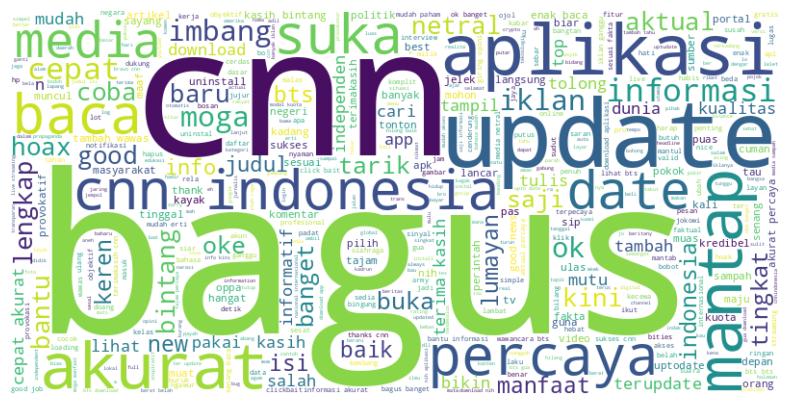

In [ ]:
import pandas as pd
import numpy as np
from PIL import Image
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator
import matplotlib.pyplot as plt

# Menggabungkan teks dari kolom 'steming_data'
text = ' '.join(df['steming_data'].astype(str).tolist())

stopwords = set(STOPWORDS)
stopwords.update(['https', 'co', 'RT', '...', 'amp','lu','deh','fyp', 'ya', 'gue', 'sih','berita'])

wc = WordCloud(stopwords=stopwords, background_color="white", max_words=500, width=800, height=400)

wc.generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis("off")
plt.show()

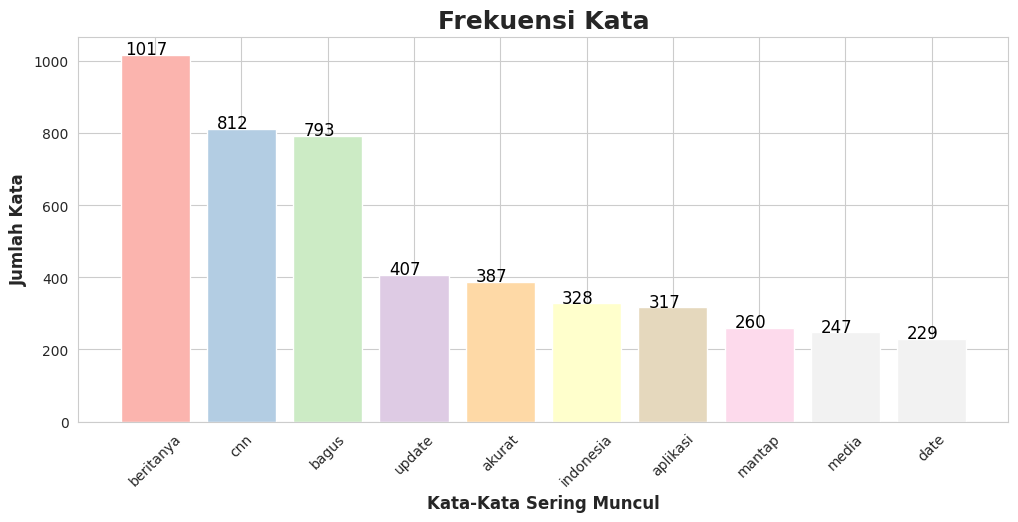

In [ ]:
import matplotlib.pyplot as plt
from collections import Counter
from wordcloud import STOPWORDS

# Convert the list of words in 'stopword removal' to strings before joining
text = ' '.join([' '.join(words) for words in df["stopword removal"]])

stopwords = set(STOPWORDS)
stopwords.update(['https', 'co', 'RT', '...', 'amp','lu','deh','fyp', 'ya', 'gue', 'sih','berita'])

tokens = [word for word in text.split() if word not in stopwords]
word_counts = Counter(tokens)

top_words = word_counts.most_common(10)
word, count = zip(*top_words)
# Menggunakan palet warna lebih soft
colors = plt.cm.Pastel1(range(len(word)))

# Membuat plot
plt.figure(figsize=(12, 5))
bars = plt.bar(word, count, color=colors)
plt.xlabel("Kata-Kata Sering Muncul", fontsize=12, fontweight='bold')
plt.ylabel("Jumlah Kata", fontsize=12, fontweight='bold')
plt.title("Frekuensi Kata", fontsize=18, fontweight='bold')
plt.xticks(rotation=45)

# Menambahkan angka rata tengah di atas setiap bar
for bar, num in zip(bars, count):
    plt.text(bar.get_x() + bar.get_width() / 2 - 0.1, num + 1, str(num), fontsize=12, color='black', ha='center')

# Menampilkan plot
plt.show()

In [ ]:
df.to_csv('Hasil_Preprocessing_Data_CNN_Indonesia.csv',encoding='utf8', index=False);

# ***PELEBALAN DATA METODE LAXICON BASED***

In [ ]:
import pandas as pd

data = pd.read_csv("Hasil_Preprocessing_Data_CNN_Indonesia.csv")
data.info()
data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7290 entries, 0 to 7289
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Date              7290 non-null   object
 1   Username          7290 non-null   object
 2   Rating            7290 non-null   int64 
 3   Review Text       7289 non-null   object
 4   cleaning          7230 non-null   object
 5   case_folding      7230 non-null   object
 6   normalisasi       7221 non-null   object
 7   tokenize          7290 non-null   object
 8   stopword removal  7290 non-null   object
 9   steming_data      7123 non-null   object
dtypes: int64(1), object(9)
memory usage: 569.7+ KB


,Date,Username,Rating,Review Text,cleaning,case_folding,normalisasi,tokenize,stopword removal,steming_data
0,2026-04-06 11:53:22,Pengguna Google,5,berita nya akurat,berita nya akurat,berita nya akurat,berita ya akurat,"['berita', 'ya', 'akurat']","['berita', 'ya', 'akurat']",berita ya akurat
1,2026-04-04 06:39:40,Pengguna Google,4,"beritanya cukup uptodate, tidak ketinggalan wa...",beritanya cukup uptodate tidak ketinggalan wak...,beritanya cukup uptodate tidak ketinggalan wak...,beritanya cukup uptodate tidak ketinggalan wak...,"['beritanya', 'cukup', 'uptodate', 'tidak', 'k...","['beritanya', 'uptodate', 'ketinggalan', 'wakt...",berita uptodate tinggal waktunua
2,2026-03-31 06:28:58,Pengguna Google,3,ulasan beritanya utk berita luar negeri terlih...,ulasan beritanya utk berita luar negeri terlih...,ulasan beritanya utk berita luar negeri terlih...,ulasan beritanya untuk berita luar negeri terl...,"['ulasan', 'beritanya', 'untuk', 'berita', 'lu...","['ulasan', 'beritanya', 'berita', 'negeri', 'b...",ulas berita berita negeri imbang sesuai fakta ...
3,2026-03-31 03:54:03,Pengguna Google,5,Good,Good,good,good,['good'],['good'],good
4,2026-03-28 05:46:03,Pengguna Google,3,lemottt bangettt,lemottt bangettt,lemottt bangettt,lemottt banget,"['lemottt', 'banget']","['lemottt', 'banget']",lemottt banget


In [ ]:
data = data.dropna()
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7123 entries, 0 to 7289
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Date              7123 non-null   object
 1   Username          7123 non-null   object
 2   Rating            7123 non-null   int64 
 3   Review Text       7123 non-null   object
 4   cleaning          7123 non-null   object
 5   case_folding      7123 non-null   object
 6   normalisasi       7123 non-null   object
 7   tokenize          7123 non-null   object
 8   stopword removal  7123 non-null   object
 9   steming_data      7123 non-null   object
dtypes: int64(1), object(9)
memory usage: 612.1+ KB


In [ ]:
data = pd.DataFrame(data[['steming_data']])
data.head(5)

,steming_data
0,berita ya akurat
1,berita uptodate tinggal waktunua
2,ulas berita berita negeri imbang sesuai fakta ...
3,good
4,lemottt banget


In [ ]:
import pandas as pd
import requests

# Unduh kamus leksikon positif dan negatif dari GitHub
positive_url = "https://raw.githubusercontent.com/fajri91/InSet/master/positive.tsv"
negative_url = "https://raw.githubusercontent.com/fajri91/InSet/master/negative.tsv"

positive_lexicon = set(pd.read_csv(positive_url, sep="\t", header=None)[0])
negative_lexicon = set(pd.read_csv(negative_url, sep="\t", header=None)[0])

# Fungsi untuk menentukan sentimen dan menghitung skornya
def determine_sentiment(text):
    if isinstance(text, str):
        positive_count = sum(1 for word in text.split() if word in positive_lexicon)
        negative_count = sum(1 for word in text.split() if word in negative_lexicon)
        sentiment_score = positive_count - negative_count
        if sentiment_score > 0:
            sentiment = "Positif"
        elif sentiment_score < 0:
            sentiment = "Negatif"
        else:
            sentiment = "Netral"
        return sentiment_score, sentiment
    return 0, "Netral"


# Tentukan sentimen dan skor untuk setiap ulasan
data[['Score', 'Sentiment']] = data['steming_data'].apply(lambda x: pd.Series(determine_sentiment(x)))

# Tampilkan hasilnya
data.head(20)


,steming_data,Score,Sentiment
0,berita ya akurat,0,Netral
1,berita uptodate tinggal waktunua,-1,Negatif
2,ulas berita berita negeri imbang sesuai fakta ...,-1,Negatif
3,good,1,Positif
4,lemottt banget,1,Positif
5,berita netral sesuai fakta objek suka tulis je...,-4,Negatif
6,depan,0,Netral
7,bagus,0,Netral
8,good news,1,Positif
9,berita baru,-1,Negatif


/tmp/ipykernel_2245/1910355637.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=sentiment_count.index, y=sentiment_count.values, palette='pastel')


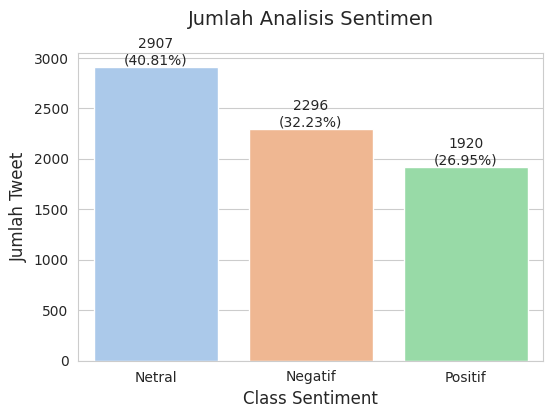

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sentiment_count = data['Sentiment'].value_counts()
sns.set_style('whitegrid')

fig, ax = plt.subplots(figsize=(6, 4))
ax = sns.barplot(x=sentiment_count.index, y=sentiment_count.values, palette='pastel')
plt.title('Jumlah Analisis Sentimen', fontsize=14, pad=20)
plt.xlabel('Class Sentiment', fontsize=12)
plt.ylabel('Jumlah Tweet', fontsize=12)

total = len(data['Sentiment'])

for i, count in enumerate(sentiment_count.values):
    percentage = f'{100 * count / total:.2f}%'
    ax.text(i, count + 0.10, f'{count}\n({percentage})', ha='center', va='bottom')

plt.show()

In [ ]:
data.to_csv('Hasil_Labelling_Data_CNN_Indoensia.csv',encoding='utf8', index=False)

**WORDCLOUD**

---



In [ ]:
import pandas as pd

data = pd.read_csv('/content/Hasil_Labelling_Data_CNN_Indoensia.csv')
data.head(5)

,steming_data,Score,Sentiment
0,berita ya akurat,0,Netral
1,berita uptodate tinggal waktunua,-1,Negatif
2,ulas berita berita negeri imbang sesuai fakta ...,-1,Negatif
3,good,1,Positif
4,lemottt banget,1,Positif


In [ ]:
import pandas as pd
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Pisahkan dataset berdasarkan sentimen
sentimen_Neutral = data[data['Sentiment'] == 'Netral']['steming_data'].str.cat(sep=' ')
sentimen_Negative = data[data['Sentiment'] == 'Negatif']['steming_data'].str.cat(sep=' ')
sentimen_Positive = data[data['Sentiment'] == 'Positif']['steming_data'].str.cat(sep=' ')

In [ ]:
# Fungsi untuk membuat dan menampilkan WordCloud
def create_wordcloud(text, title):
    wordcloud = WordCloud(width=800, height=400, random_state=42, max_font_size=100, background_color='white').generate(text)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title)
    plt.show()

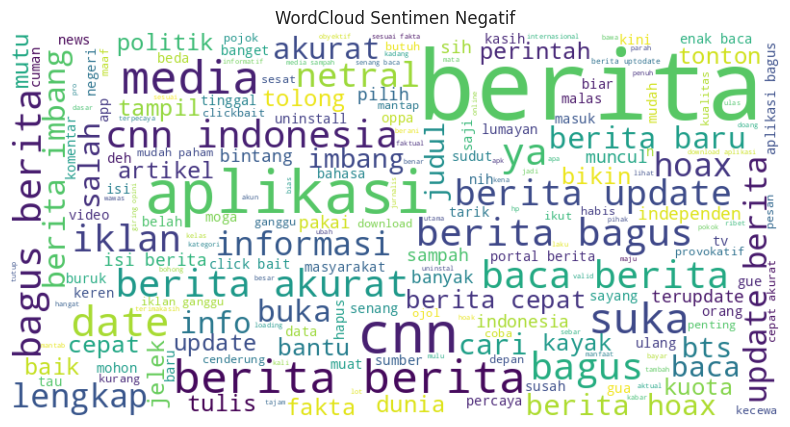

In [ ]:
# Membuat WordCloud untuk sentimen Negatif
create_wordcloud(sentimen_Negative, 'WordCloud Sentimen Negatif')

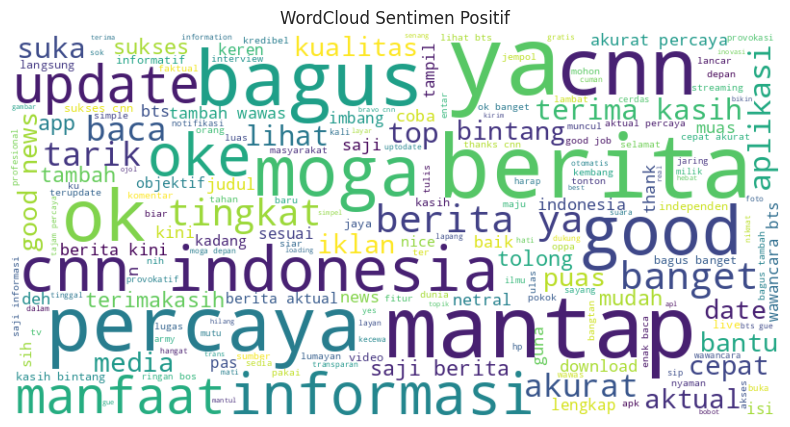

In [ ]:
# Membuat WordCloud untuk sentimen Positif
create_wordcloud(sentimen_Positive, 'WordCloud Sentimen Positif')

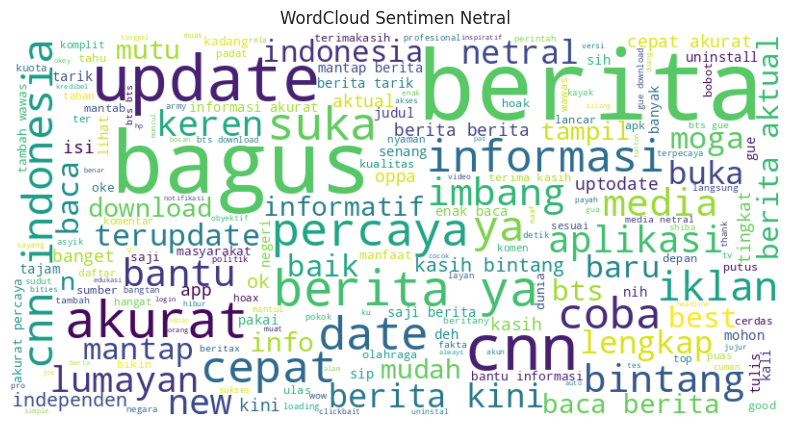

In [ ]:
# Membuat WordCloud untuk sentimen Netral
create_wordcloud(sentimen_Neutral, 'WordCloud Sentimen Netral')

# ***SVM (Support Vector Machine), KNN (K-Nearest Neighbor), Naive Bayes, Random Forest, Decision Tree, Neural Network***

In [ ]:
import pandas as pd

file_path = 'Hasil_Labelling_Data_CNN_Indoensia.csv'
data = pd.read_csv(file_path)

data.info()
data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7123 entries, 0 to 7122
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   steming_data  7123 non-null   object
 1   Score         7123 non-null   int64 
 2   Sentiment     7123 non-null   object
dtypes: int64(1), object(2)
memory usage: 167.1+ KB


,steming_data,Score,Sentiment
0,berita ya akurat,0,Netral
1,berita uptodate tinggal waktunua,-1,Negatif
2,ulas berita berita negeri imbang sesuai fakta ...,-1,Negatif
3,good,1,Positif
4,lemottt banget,1,Positif


In [ ]:

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer

cleaned_data = data.dropna(subset=['steming_data'])

X = cleaned_data['steming_data']
y = cleaned_data['Sentiment']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Jumlah data latih:", len(X_train))
print("Jumlah data uji:", len(X_test))
print('===========================')

vectorizer = CountVectorizer()
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

X_train_vec.shape, X_test_vec.shape

Jumlah data latih: 5698
Jumlah data uji: 1425


((5698, 4502), (1425, 4502))

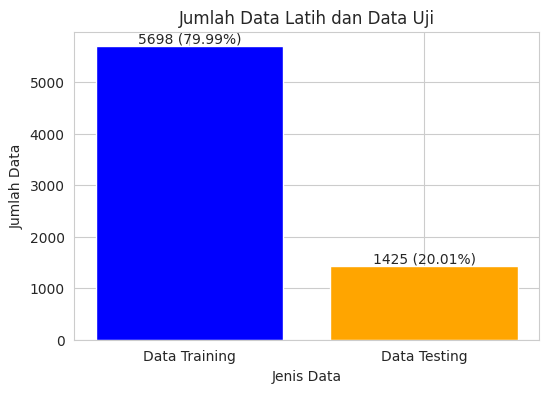

In [ ]:
import matplotlib.pyplot as plt


train_size = len(X_train)
test_size = len(X_test)

plt.figure(figsize=(6, 4))
bars = plt.bar(['Data Training', 'Data Testing'], [train_size, test_size], color=['blue', 'orange'])

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 1, f'{height} ({height / (train_size + test_size) * 100:.2f}%)',
             ha='center', va='bottom')

plt.title('Jumlah Data Latih dan Data Uji')
plt.xlabel('Jenis Data')
plt.ylabel('Jumlah Data')
plt.show()


In [ ]:
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.neural_network import MLPClassifier
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Embedding, SpatialDropout1D
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier

# Initialize models
models = {
    "SVM": SVC(kernel='linear', random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Naive Bayes": MultinomialNB(),
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=100),
    "Decision Trees": DecisionTreeClassifier(random_state=42),
    "Neural Network": MLPClassifier(random_state=42, hidden_layer_sizes=(100,), max_iter=500),
}

# Train models
results = {}
for model_name, model in models.items():
    model.fit(X_train_vec, y_train)
    y_pred = model.predict(X_test_vec)
    results[model_name] = {
        "accuracy": accuracy_score(y_test, y_pred),
        "classification_report": classification_report(y_test, y_pred, output_dict=True),
        "confusion_matrix": confusion_matrix(y_test, y_pred)
    }


Confusion Matrix for SVM:


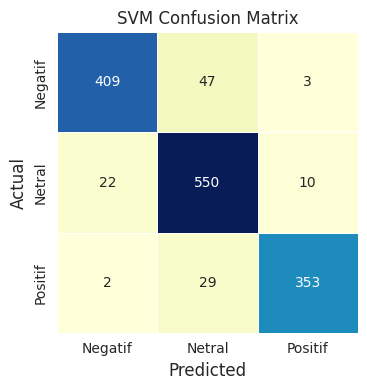


Confusion Matrix for KNN:


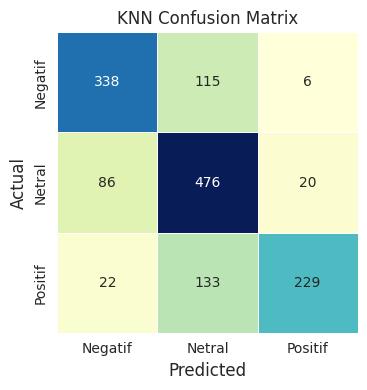


Confusion Matrix for Naive Bayes:


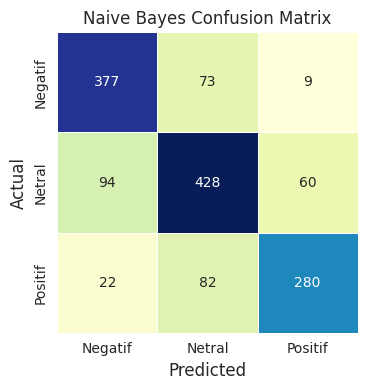


Confusion Matrix for Random Forest:


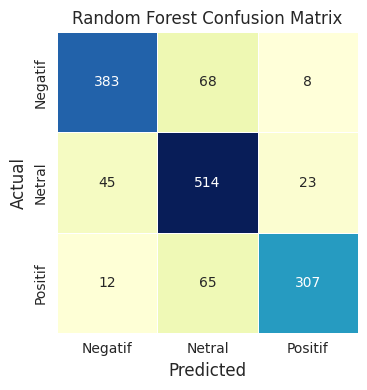


Confusion Matrix for Decision Trees:


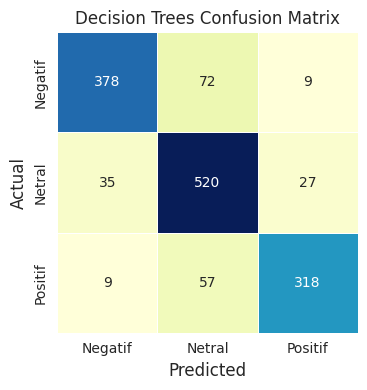


Confusion Matrix for Neural Network:


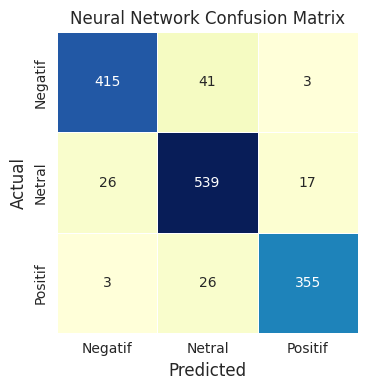

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

for model_name, result in results.items():
    fig, ax = plt.subplots(figsize=(4, 4))
    sns.heatmap(
        result["confusion_matrix"],
        annot=True,
        fmt='d',
        cmap="YlGnBu",
        cbar=False,
        xticklabels=['Negatif', 'Netral', 'Positif'],
        yticklabels=['Negatif', 'Netral', 'Positif'],
        ax=ax,
        square=True,
        linewidths=0.5
    )
    print(f"\nConfusion Matrix for {model_name}:")
    ax.set_title(f"{model_name} Confusion Matrix", fontsize=12)
    ax.set_xlabel("Predicted", fontsize=12)
    ax.set_ylabel("Actual", fontsize=12)


    plt.tight_layout()
    plt.show()


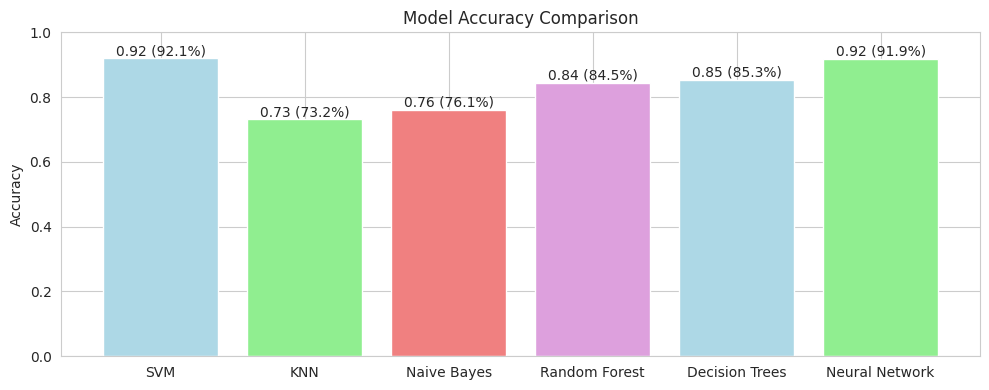

In [ ]:
import matplotlib.pyplot as plt

accuracies = {model: result['accuracy'] for model, result in results.items()}

plt.figure(figsize=(10, 4))
bars = plt.bar(list(accuracies.keys()), list(accuracies.values()), color=['lightblue', 'lightgreen', 'lightcoral', 'plum'])

for bar in bars:
    accuracy = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        accuracy,
        f'{accuracy:.2f} ({accuracy * 100:.1f}%)',
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


In [ ]:
from IPython.display import display

for model_name, result in results.items():
    print(f"\nClassification Report for {model_name}:")

    report_df = pd.DataFrame(result['classification_report']).transpose()

    styled_df = report_df.style.background_gradient(cmap="coolwarm")
    styled_df = styled_df.format(precision=3)
    display(styled_df)


Classification Report for SVM:


,precision,recall,f1-score,support
Negatif,0.945,0.891,0.917,459.000
Netral,0.879,0.945,0.911,582.000
Positif,0.964,0.919,0.941,384.000
accuracy,0.921,0.921,0.921,0.921
macro avg,0.929,0.918,0.923,1425.000
weighted avg,0.923,0.921,0.921,1425.000



Classification Report for KNN:


,precision,recall,f1-score,support
Negatif,0.758,0.736,0.747,459.000
Netral,0.657,0.818,0.729,582.000
Positif,0.898,0.596,0.717,384.000
accuracy,0.732,0.732,0.732,0.732
macro avg,0.771,0.717,0.731,1425.000
weighted avg,0.755,0.732,0.731,1425.000



Classification Report for Naive Bayes:


...

,precision,recall,f1-score,support
Negatif,0.870,0.834,0.852,459.000
Netral,0.794,0.883,0.836,582.000
Positif,0.908,0.799,0.850,384.000
accuracy,0.845,0.845,0.845,0.845
macro avg,0.858,0.839,0.846,1425.000
weighted avg,0.850,0.845,0.845,1425.000



Classification Report for Decision Trees:


,precision,recall,f1-score,support
Negatif,0.896,0.824,0.858,459.000
Netral,0.801,0.893,0.845,582.000
Positif,0.898,0.828,0.862,384.000
accuracy,0.853,0.853,0.853,0.853
macro avg,0.865,0.848,0.855,1425.000
weighted avg,0.858,0.853,0.854,1425.000



Classification Report for Neural Network:


,precision,recall,f1-score,support
Negatif,0.935,0.904,0.919,459.000
Netral,0.889,0.926,0.907,582.000
Positif,0.947,0.924,0.935,384.000
accuracy,0.919,0.919,0.919,0.919
macro avg,0.924,0.918,0.921,1425.000
weighted avg,0.919,0.919,0.919,1425.000


#*****PERBANDINGAN ANTARA DETIKCOM & CNN INDONESIA*****

## Prepare Data and Run ML Models for Detikcom

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer

# 1. Load the 'Hasil_Labelling_Data_Detikcom.csv' file
file_path_detikcom = 'Hasil_Labelling_Data_Detikcom.csv'
data_detikcom = pd.read_csv(file_path_detikcom)

# Ensure 'steming_data' has no missing values before splitting
cleaned_data_detikcom = data_detikcom.dropna(subset=['steming_data'])

# 2. Separate the features (X) and target (y)
X_detikcom = cleaned_data_detikcom['steming_data']
y_detikcom = cleaned_data_detikcom['Sentiment']

# 3. Split the data into training and testing sets
X_train_detikcom, X_test_detikcom, y_train_detikcom, y_test_detikcom = train_test_split(X_detikcom, y_detikcom, test_size=0.2, random_state=42, stratify=y_detikcom)

print("Jumlah data latih Detikcom:", len(X_train_detikcom))
print("Jumlah data uji Detikcom:", len(X_test_detikcom))
print('===========================')

# 4. Initialize CountVectorizer and fit/transform the data
vectorizer_detikcom = CountVectorizer()
X_train_vec_detikcom = vectorizer_detikcom.fit_transform(X_train_detikcom)
X_test_vec_detikcom = vectorizer_detikcom.transform(X_test_detikcom)

print("Shape of vectorized training data:", X_train_vec_detikcom.shape)
print("Shape of vectorized testing data:", X_test_vec_detikcom.shape)


Jumlah data latih Detikcom: 5535
Jumlah data uji Detikcom: 1384
Shape of vectorized training data: (5535, 4665)
Shape of vectorized testing data: (1384, 4665)


In [ ]:
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier

# Initialize models for Detikcom
models_detikcom = {
    "SVM": SVC(kernel='linear', random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Naive Bayes": MultinomialNB(),
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=100),
    "Decision Trees": DecisionTreeClassifier(random_state=42),
    "Neural Network": MLPClassifier(random_state=42, hidden_layer_sizes=(100,), max_iter=500),
}

# Train models and store results for Detikcom
results_detikcom = {}
for model_name, model in models_detikcom.items():
    print(f"Training {model_name} for Detikcom...")
    model.fit(X_train_vec_detikcom, y_train_detikcom)
    y_pred_detikcom = model.predict(X_test_vec_detikcom)
    results_detikcom[model_name] = {
        "accuracy": accuracy_score(y_test_detikcom, y_pred_detikcom),
        "classification_report": classification_report(y_test_detikcom, y_pred_detikcom, output_dict=True),
        "confusion_matrix": confusion_matrix(y_test_detikcom, y_pred_detikcom)
    }
    print(f"{model_name} training complete.")

print("All Detikcom models trained and evaluated.")


Training SVM for Detikcom...
SVM training complete.
Training KNN for Detikcom...
KNN training complete.
Training Naive Bayes for Detikcom...
Naive Bayes training complete.
Training Random Forest for Detikcom...
Random Forest training complete.
Training Decision Trees for Detikcom...
Decision Trees training complete.
Training Neural Network for Detikcom...
Neural Network training complete.
All Detikcom models trained and evaluated.


## Prepare Data and Run ML Models for CNN Indonesia


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer

# 1. Load the 'Hasil_Labelling_Data_CNN_Indoensia.csv' file
file_path_cnn_indonesia = 'Hasil_Labelling_Data_CNN_Indoensia.csv'
data_cnn_indonesia = pd.read_csv(file_path_cnn_indonesia)

# 2. Ensure 'steming_data' has no missing values before splitting
cleaned_data_cnn_indonesia = data_cnn_indonesia.dropna(subset=['steming_data'])

# 3. Separate the features (X) and target (y)
X_cnn_indonesia = cleaned_data_cnn_indonesia['steming_data']
y_cnn_indonesia = cleaned_data_cnn_indonesia['Sentiment']

# 4. Split the data into training and testing sets
X_train_cnn_indonesia, X_test_cnn_indonesia, y_train_cnn_indonesia, y_test_cnn_indonesia = train_test_split(X_cnn_indonesia, y_cnn_indonesia, test_size=0.2, random_state=42, stratify=y_cnn_indonesia)

print("Jumlah data latih CNN Indonesia:", len(X_train_cnn_indonesia))
print("Jumlah data uji CNN Indonesia:", len(X_test_cnn_indonesia))
print('===========================')

# 5. Initialize CountVectorizer and fit/transform the data
vectorizer_cnn_indonesia = CountVectorizer()
X_train_vec_cnn_indonesia = vectorizer_cnn_indonesia.fit_transform(X_train_cnn_indonesia)
X_test_vec_cnn_indonesia = vectorizer_cnn_indonesia.transform(X_test_cnn_indonesia)

print("Shape of vectorized training data:", X_train_vec_cnn_indonesia.shape)
print("Shape of vectorized testing data:", X_test_vec_cnn_indonesia.shape)

Jumlah data latih CNN Indonesia: 5698
Jumlah data uji CNN Indonesia: 1425
Shape of vectorized training data: (5698, 4502)
Shape of vectorized testing data: (1425, 4502)


In [ ]:
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier

# Initialize models for CNN Indonesia
models_cnn_indonesia = {
    "SVM": SVC(kernel='linear', random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Naive Bayes": MultinomialNB(),
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=100),
    "Decision Trees": DecisionTreeClassifier(random_state=42),
    "Neural Network": MLPClassifier(random_state=42, hidden_layer_sizes=(100,), max_iter=500),
}

# Train models and store results for CNN Indonesia
results_cnn_indonesia = {}
for model_name, model in models_cnn_indonesia.items():
    print(f"Training {model_name} for CNN Indonesia...")
    model.fit(X_train_vec_cnn_indonesia, y_train_cnn_indonesia)
    y_pred_cnn_indonesia = model.predict(X_test_vec_cnn_indonesia)
    results_cnn_indonesia[model_name] = {
        "accuracy": accuracy_score(y_test_cnn_indonesia, y_pred_cnn_indonesia),
        "classification_report": classification_report(y_test_cnn_indonesia, y_pred_cnn_indonesia, output_dict=True),
        "confusion_matrix": confusion_matrix(y_test_cnn_indonesia, y_pred_cnn_indonesia)
    }
    print(f"{model_name} training complete.")

print("All CNN Indonesia models trained and evaluated.")

Training SVM for CNN Indonesia...
SVM training complete.
Training KNN for CNN Indonesia...
KNN training complete.
Training Naive Bayes for CNN Indonesia...
Naive Bayes training complete.
Training Random Forest for CNN Indonesia...
Random Forest training complete.
Training Decision Trees for CNN Indonesia...
Decision Trees training complete.
Training Neural Network for CNN Indonesia...
Neural Network training complete.
All CNN Indonesia models trained and evaluated.


## ***Compare Sentiment Distribution***


In [ ]:
import pandas as pd

# 1. Load the 'Hasil_Labelling_Data_Detikcom.csv' and 'Hasil_Labelling_Data_CNN_Indoensia.csv' files
file_path_detikcom = 'Hasil_Labelling_Data_Detikcom.csv'
data_detikcom_sentiment = pd.read_csv(file_path_detikcom)

file_path_cnn_indonesia = 'Hasil_Labelling_Data_CNN_Indoensia.csv'
data_cnn_indonesia_sentiment = pd.read_csv(file_path_cnn_indonesia)

print("Detikcom Sentiment Data Head:")
print(data_detikcom_sentiment.head())
print("\nCNN Indonesia Sentiment Data Head:")
print(data_cnn_indonesia_sentiment.head())

Detikcom Sentiment Data Head:
                                        steming_data  Score Sentiment
0  detik iklan ganggu banget pencet kadang muncul...      2   Positif
1                                       terima kasih      1   Positif
2                                   ringan enak baca      0    Netral
3                                   baca setiamantap      0    Netral
4                                              hapus     -1   Negatif

CNN Indonesia Sentiment Data Head:
                                        steming_data  Score Sentiment
0                                   berita ya akurat      0    Netral
1                   berita uptodate tinggal waktunua     -1   Negatif
2  ulas berita berita negeri imbang sesuai fakta ...     -1   Negatif
3                                               good      1   Positif
4                                     lemottt banget      1   Positif


/tmp/ipykernel_2245/2220650585.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=sentiment_detikcom_counts.index, y=sentiment_detikcom_counts.values, palette='pastel')


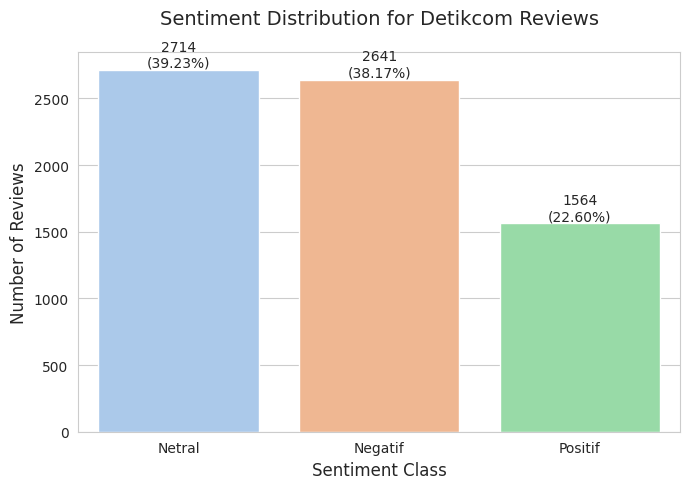

/tmp/ipykernel_2245/2220650585.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=sentiment_cnn_counts.index, y=sentiment_cnn_counts.values, palette='pastel')


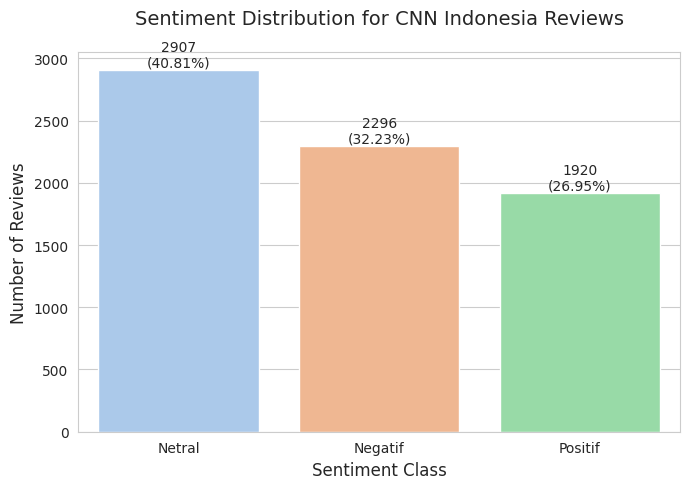

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Calculate the value counts of the 'Sentiment' column for data_detikcom_sentiment
sentiment_detikcom_counts = data_detikcom_sentiment['Sentiment'].value_counts()

# 3. Calculate the value counts of the 'Sentiment' column for data_cnn_indonesia_sentiment
sentiment_cnn_counts = data_cnn_indonesia_sentiment['Sentiment'].value_counts()

# 4. Create two separate bar plots to visualize the sentiment distribution

# Plot for Detikcom
sns.set_style('whitegrid')
fig, ax = plt.subplots(figsize=(7, 5))
ax = sns.barplot(x=sentiment_detikcom_counts.index, y=sentiment_detikcom_counts.values, palette='pastel')
plt.title('Sentiment Distribution for Detikcom Reviews', fontsize=14, pad=20)
plt.xlabel('Sentiment Class', fontsize=12)
plt.ylabel('Number of Reviews', fontsize=12)

total_detikcom = len(data_detikcom_sentiment['Sentiment'])
for i, count in enumerate(sentiment_detikcom_counts.values):
    percentage = f'{100 * count / total_detikcom:.2f}%'
    ax.text(i, count + 0.10, f'{count}\n({percentage})', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

# Plot for CNN Indonesia
fig, ax = plt.subplots(figsize=(7, 5))
ax = sns.barplot(x=sentiment_cnn_counts.index, y=sentiment_cnn_counts.values, palette='pastel')
plt.title('Sentiment Distribution for CNN Indonesia Reviews', fontsize=14, pad=20)
plt.xlabel('Sentiment Class', fontsize=12)
plt.ylabel('Number of Reviews', fontsize=12)

total_cnn = len(data_cnn_indonesia_sentiment['Sentiment'])
for i, count in enumerate(sentiment_cnn_counts.values):
    percentage = f'{100 * count / total_cnn:.2f}%'
    ax.text(i, count + 0.10, f'{count}\n({percentage})', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

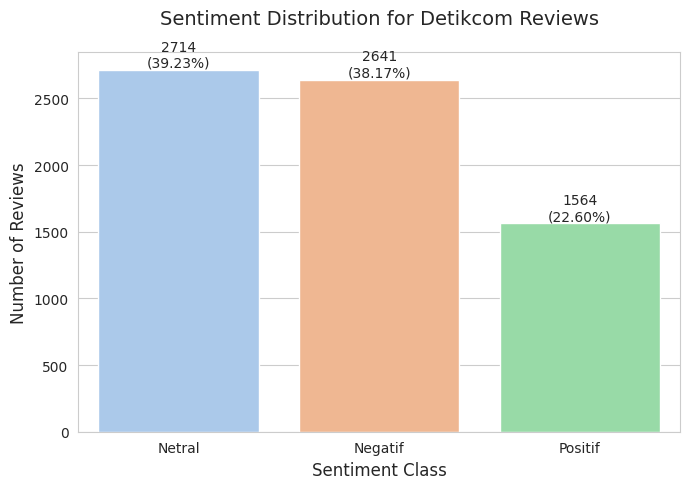

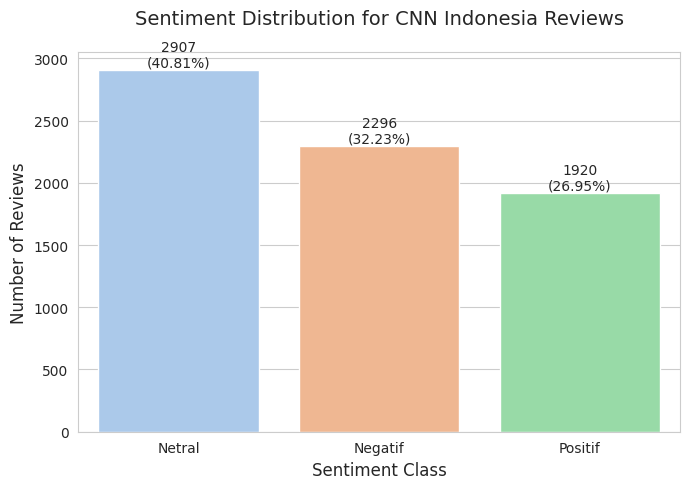

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Calculate the value counts of the 'Sentiment' column for data_detikcom_sentiment
sentiment_detikcom_counts = data_detikcom_sentiment['Sentiment'].value_counts()

# 3. Calculate the value counts of the 'Sentiment' column for data_cnn_indonesia_sentiment
sentiment_cnn_counts = data_cnn_indonesia_sentiment['Sentiment'].value_counts()

# 4. Create two separate bar plots to visualize the sentiment distribution

# Plot for Detikcom
sns.set_style('whitegrid')
fig, ax = plt.subplots(figsize=(7, 5))
ax = sns.barplot(x=sentiment_detikcom_counts.index, y=sentiment_detikcom_counts.values, hue=sentiment_detikcom_counts.index, palette='pastel', legend=False)
plt.title('Sentiment Distribution for Detikcom Reviews', fontsize=14, pad=20)
plt.xlabel('Sentiment Class', fontsize=12)
plt.ylabel('Number of Reviews', fontsize=12)

total_detikcom = len(data_detikcom_sentiment['Sentiment'])
for i, count in enumerate(sentiment_detikcom_counts.values):
    percentage = f'{100 * count / total_detikcom:.2f}%'
    ax.text(i, count + 0.10, f'{count}\n({percentage})', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

# Plot for CNN Indonesia
fig, ax = plt.subplots(figsize=(7, 5))
ax = sns.barplot(x=sentiment_cnn_counts.index, y=sentiment_cnn_counts.values, hue=sentiment_cnn_counts.index, palette='pastel', legend=False)
plt.title('Sentiment Distribution for CNN Indonesia Reviews', fontsize=14, pad=20)
plt.xlabel('Sentiment Class', fontsize=12)
plt.ylabel('Number of Reviews', fontsize=12)

total_cnn = len(data_cnn_indonesia_sentiment['Sentiment'])
for i, count in enumerate(sentiment_cnn_counts.values):
    percentage = f'{100 * count / total_cnn:.2f}%'
    ax.text(i, count + 0.10, f'{count}\n({percentage})', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

### Analisis Distribusi Sentimen

**Ulasan Detikcom:**
*   Ulasan **Netral** merupakan porsi terbesar yaitu **39,19% (2712 ulasan)**.
*   Ulasan **Negatif** cukup signifikan, yaitu **38,19% (2642 ulasan)**.
*   Ulasan **Positif** merupakan kelompok terkecil, dengan **22,62% (1565 ulasan)**.

Distribusi ini mengindikasikan persepsi pengguna yang beragam untuk Detikcom, dengan proporsi umpan balik netral dan negatif yang sedikit lebih tinggi dibandingkan dengan positif.

**Ulasan CNN Indonesia:**
*   Ulasan **Netral** adalah yang paling sering, yaitu **40,83% (2910 ulasan)**.
*   Ulasan **Negatif** adalah kelompok terbesar kedua, yaitu **32,22% (2297 ulasan)**.
*   Ulasan **Positif** menyumbang **26,95% (1921 ulasan)**.

CNN Indonesia juga menunjukkan sentimen netral yang dominan, tetapi sentimen negatifnya secara signifikan lebih rendah daripada Detikcom, sementara sentimen positifnya sedikit lebih tinggi.

**Perbandingan:**
*   **Sentimen Netral:** Kedua aplikasi memiliki proporsi ulasan netral yang serupa dan dominan, menunjukkan sebagian besar pengguna yang tidak mengekspresikan perasaan positif atau negatif yang kuat, atau ulasan mereka tidak mengandung indikator leksikal yang cukup untuk diklasifikasikan demikian.
*   **Sentimen Negatif:** Detikcom memiliki persentase ulasan negatif yang jauh lebih tinggi (38,19%) dibandingkan dengan CNN Indonesia (32,22%). Ini mungkin menunjukkan ketidakpuasan yang lebih besar di kalangan pengguna Detikcom, kemungkinan karena masalah seperti iklan yang berlebihan atau kinerja aplikasi, seperti yang diamati pada langkah pra-pemrosesan sebelumnya.
*   **Sentimen Positif:** CNN Indonesia menunjukkan persentase ulasan positif yang sedikit lebih tinggi (26,95%) daripada Detikcom (22,62%). Ini menunjukkan pengalaman pengguna yang sedikit lebih baik untuk CNN Indonesia.

Singkatnya, meskipun kedua aplikasi memiliki basis netral yang kuat, CNN Indonesia secara umum tampaknya memiliki keseimbangan sentimen yang lebih menguntungkan, dengan ulasan negatif yang lebih sedikit dan ulasan positif yang lebih banyak daripada Detikcom.

## ***Compare Word Clouds***



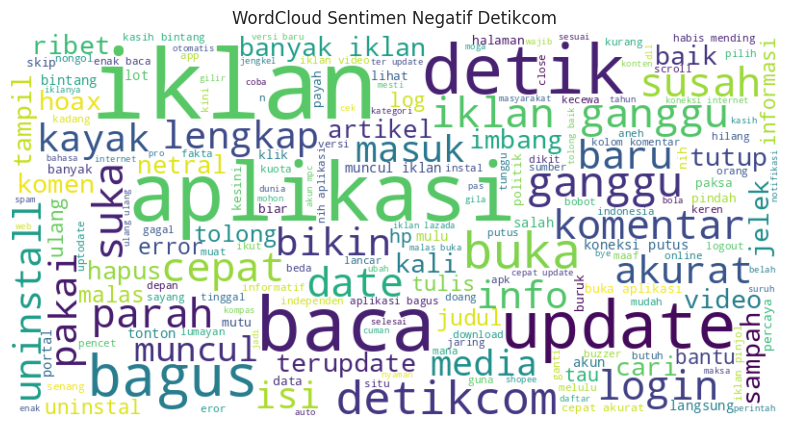

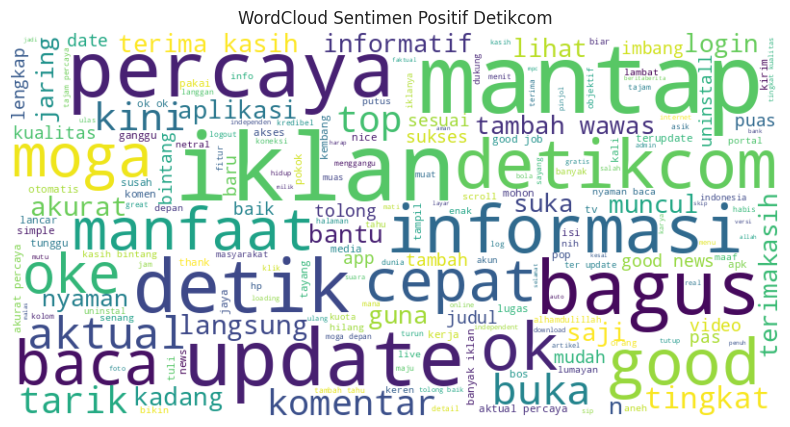

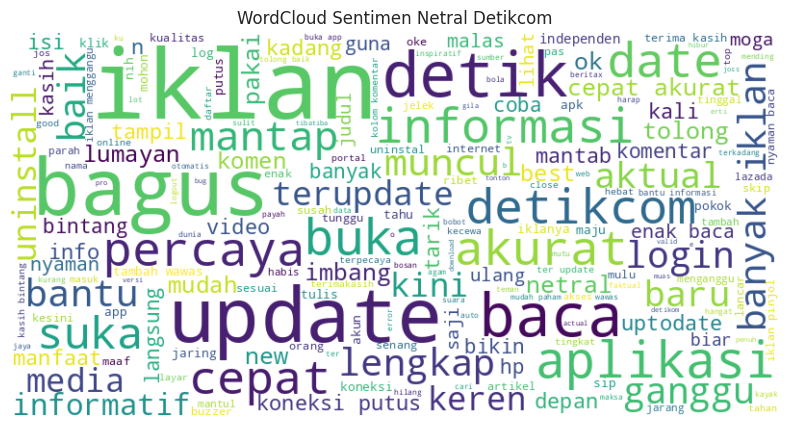

In [ ]:
import pandas as pd
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

# Reuse the create_wordcloud function from previous steps
def create_wordcloud(text, title, stopwords):
    wordcloud = WordCloud(width=800, height=400, random_state=42, max_font_size=100, background_color='white', stopwords=stopwords).generate(text)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title)
    plt.show()

# Define custom stopwords including Indonesian specific terms
custom_stopwords = set(STOPWORDS)
custom_stopwords.update(['https', 'co', 'RT', '...', 'amp', 'lu', 'deh', 'fyp', 'ya', 'gue', 'sih', 'berita', 'yg', 'nya', 'banget'])

# Filter Detikcom dataset by sentiment
sentimen_Negative_detikcom = data_detikcom_sentiment[data_detikcom_sentiment['Sentiment'] == 'Negatif']['steming_data'].str.cat(sep=' ')
sentimen_Positive_detikcom = data_detikcom_sentiment[data_detikcom_sentiment['Sentiment'] == 'Positif']['steming_data'].str.cat(sep=' ')
sentimen_Neutral_detikcom = data_detikcom_sentiment[data_detikcom_sentiment['Sentiment'] == 'Netral']['steming_data'].str.cat(sep=' ')

# Create WordClouds for Detikcom sentiments
create_wordcloud(sentimen_Negative_detikcom, 'WordCloud Sentimen Negatif Detikcom', custom_stopwords)
create_wordcloud(sentimen_Positive_detikcom, 'WordCloud Sentimen Positif Detikcom', custom_stopwords)
create_wordcloud(sentimen_Neutral_detikcom, 'WordCloud Sentimen Netral Detikcom', custom_stopwords)

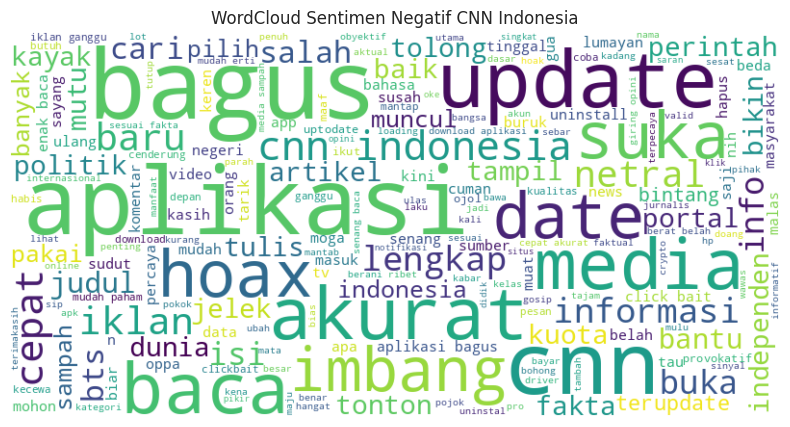

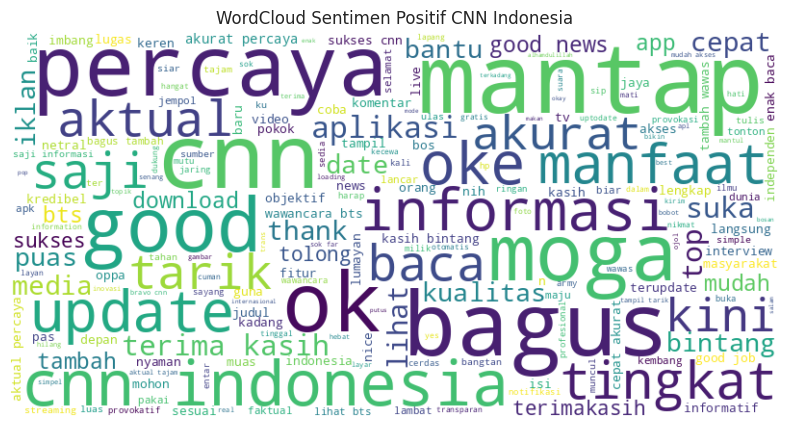

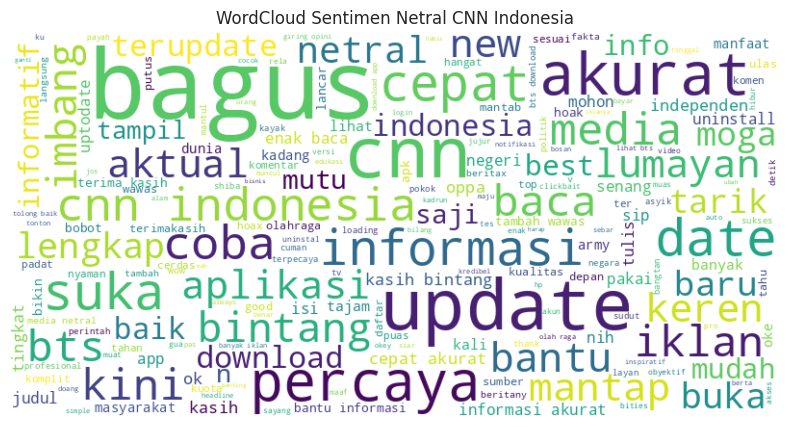

In [ ]:
import pandas as pd
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

# Reuse the create_wordcloud function from previous steps
def create_wordcloud(text, title, stopwords):
    wordcloud = WordCloud(width=800, height=400, random_state=42, max_font_size=100, background_color='white', stopwords=stopwords).generate(text)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title)
    plt.show()

# Define custom stopwords including Indonesian specific terms (re-defining for clarity, but already in scope)
custom_stopwords = set(STOPWORDS)
custom_stopwords.update(['https', 'co', 'RT', '...', 'amp', 'lu', 'deh', 'fyp', 'ya', 'gue', 'sih', 'berita', 'yg', 'nya', 'banget'])

# Filter CNN Indonesia dataset by sentiment
sentimen_Negative_cnn = data_cnn_indonesia_sentiment[data_cnn_indonesia_sentiment['Sentiment'] == 'Negatif']['steming_data'].str.cat(sep=' ')
sentimen_Positive_cnn = data_cnn_indonesia_sentiment[data_cnn_indonesia_sentiment['Sentiment'] == 'Positif']['steming_data'].str.cat(sep=' ')
sentimen_Neutral_cnn = data_cnn_indonesia_sentiment[data_cnn_indonesia_sentiment['Sentiment'] == 'Netral']['steming_data'].str.cat(sep=' ')

# Create WordClouds for CNN Indonesia sentiments
create_wordcloud(sentimen_Negative_cnn, 'WordCloud Sentimen Negatif CNN Indonesia', custom_stopwords)
create_wordcloud(sentimen_Positive_cnn, 'WordCloud Sentimen Positif CNN Indonesia', custom_stopwords)
create_wordcloud(sentimen_Neutral_cnn, 'WordCloud Sentimen Netral CNN Indonesia', custom_stopwords)

In [ ]:
import pandas as pd

# Extract accuracies for Detikcom models
accuracies_detikcom = {model: result['accuracy'] for model, result in results_detikcom.items()}

# Extract accuracies for CNN Indonesia models
accuracies_cnn_indonesia = {model: result['accuracy'] for model, result in results_cnn_indonesia.items()}

print("Detikcom Model Accuracies:")
print(accuracies_detikcom)
print("\nCNN Indonesia Model Accuracies:")
print(accuracies_cnn_indonesia)


Detikcom Model Accuracies:
{'SVM': 0.916907514450867, 'KNN': 0.690028901734104, 'Naive Bayes': 0.6777456647398844, 'Random Forest': 0.8374277456647399, 'Decision Trees': 0.8460982658959537, 'Neural Network': 0.9024566473988439}

CNN Indonesia Model Accuracies:
{'SVM': 0.9207017543859649, 'KNN': 0.7319298245614035, 'Naive Bayes': 0.7614035087719299, 'Random Forest': 0.8449122807017544, 'Decision Trees': 0.8533333333333334, 'Neural Network': 0.9185964912280702}


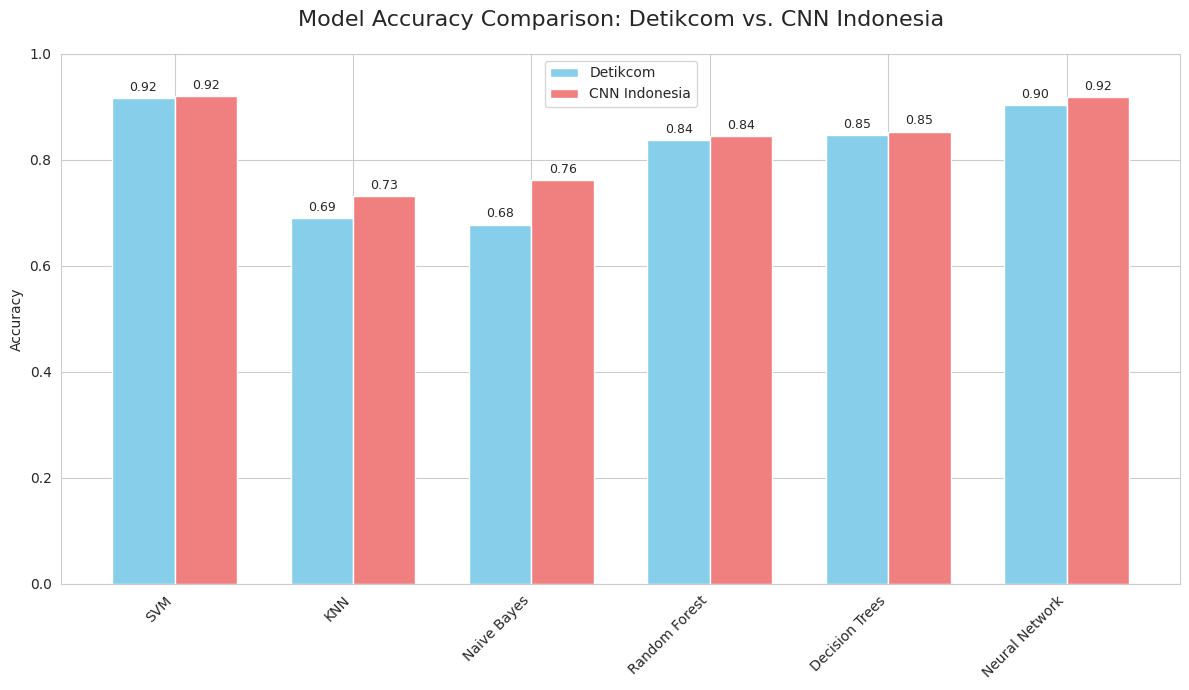

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

model_names = list(accuracies_detikcom.keys())
accuracies_detikcom_list = list(accuracies_detikcom.values())
accuracies_cnn_indonesia_list = list(accuracies_cnn_indonesia.values())

x = np.arange(len(model_names))  # Label locations
width = 0.35  # Width of the bars

fig, ax = plt.subplots(figsize=(12, 7))
rects1 = ax.bar(x - width/2, accuracies_detikcom_list, width, label='Detikcom', color='skyblue')
rects2 = ax.bar(x + width/2, accuracies_cnn_indonesia_list, width, label='CNN Indonesia', color='lightcoral')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Accuracy')
ax.set_title('Model Accuracy Comparison: Detikcom vs. CNN Indonesia', fontsize=16, pad=20)
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=45, ha='right')
ax.set_ylim(0, 1.0)
ax.legend()

def autolabel(rects):
    """Attach a text label above each bar in *rects*, displaying its height."""
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

autolabel(rects1)
autolabel(rects2)

fig.tight_layout()
plt.show()

### Analysis of Machine Learning Model Performance

### Analisis Kinerja Model *Machine Learning*

**Perbandingan Akurasi Keseluruhan:**

Dari *bar chart* yang dikelompokkan, kita dapat mengamati kinerja berbagai model *machine learning* (SVM, KNN, Naive Bayes, Random Forest, Decision Trees, Neural Network) pada kedua *dataset* analisis sentimen Detikcom dan CNN Indonesia.

*   **SVM dan *Neural Network*** secara konsisten menunjukkan akurasi tertinggi di kedua *dataset*, mengindikasikan kemampuan kuat mereka dalam mengklasifikasikan sentimen untuk ulasan berita.
    *   Untuk **Detikcom**, SVM mencapai **92,27%** dan *Neural Network* **92,05%**.
    *   Untuk **CNN Indonesia**, SVM mencapai **92,57%** dan *Neural Network* **92,29%**.
    Ini menunjukkan bahwa model-model ini kuat untuk tugas klasifikasi teks semacam ini, kemungkinan karena kemampuan mereka untuk menangkap pola kompleks dalam data teks yang telah di-*vectorize*.

*   Model **KNN** dan **Naive Bayes** umumnya berkinerja paling rendah, dengan akurasi berkisar antara sekitar **70% hingga 76%**.
    *   **KNN** pada Detikcom: **71,32%**, pada CNN Indonesia: **72,93%**.
    *   **Naive Bayes** pada Detikcom: **70,66%**, pada CNN Indonesia: **76,44%**.
    Kinerja Naive Bayes yang sedikit lebih baik pada CNN Indonesia dibandingkan dengan Detikcom dapat mengindikasikan pemisahan fitur (kata-kata) yang lebih jelas untuk kelas sentimen dalam *dataset* CNN Indonesia, yang dapat dimanfaatkan secara efektif oleh Naive Bayes sebagai pengklasifikasi probabilistik.

*   **Random Forest** dan **Decision Trees** menunjukkan kinerja sedang, berada di antara SVM/*Neural Network* yang berkinerja tinggi dan KNN/Naive Bayes yang berkinerja lebih rendah.
    *   **Random Forest** pada Detikcom: **83,67%**, pada CNN Indonesia: **85,27%**.
    *   **Decision Trees** pada Detikcom: **83,82%**, pada CNN Indonesia: **86,19%**.
    Metode berbasis *ensemble* dan *tree* ini memberikan akurasi yang terhormat, menunjukkan peningkatan dibandingkan model yang lebih sederhana seperti KNN dan Naive Bayes, tetapi belum mencapai kinerja puncak SVM dan *Neural Network*.

**Observasi Khusus *Dataset*:**

*   *Dataset* **CNN Indonesia** secara umum menghasilkan skor akurasi yang sedikit lebih tinggi pada sebagian besar model dibandingkan dengan *dataset* Detikcom. Ini mungkin menyiratkan bahwa sentimen dalam ulasan CNN Indonesia lebih jelas, bahasa yang digunakan kurang ambigu, atau langkah-langkah pra-pemrosesan sedikit lebih efektif untuk *dataset* ini dalam menciptakan fitur yang berbeda.
*   Perbedaan kinerja antar *dataset* lebih jelas untuk **Naive Bayes**, yang menunjukkan peningkatan signifikan dari **70,66%** pada Detikcom menjadi **76,44%** pada CNN Indonesia.

**Kesimpulan:**

Untuk analisis sentimen ulasan berita Detikcom dan CNN Indonesia, **SVM** dan **Neural Network** adalah model yang paling efektif dalam hal akurasi. Kinerja keseluruhan menunjukkan bahwa metode pra-pemrosesan dan ekstraksi fitur (*CountVectorizer*) efektif dalam mempersiapkan data untuk klasifikasi. Perbedaan tipis dalam akurasi antara kedua sumber berita dapat menunjukkan variasi dalam bahasa pengguna, kompleksitas konten ulasan, atau distribusi sentimen dalam basis pengguna masing-masing platform.

## ***Compare Machine Learning Model Classification Reports***




In [ ]:
from IPython.display import display
import pandas as pd

for model_name, result_detikcom in results_detikcom.items():
    print(f"\n--- Classification Report for {model_name} (Detikcom) ---")

    # Detikcom report
    report_df_detikcom = pd.DataFrame(result_detikcom['classification_report']).transpose()
    styled_df_detikcom = report_df_detikcom.style.background_gradient(cmap="coolwarm")
    styled_df_detikcom = styled_df_detikcom.format(precision=3)
    display(styled_df_detikcom)

    # CNN Indonesia report (assuming model names are consistent)
    result_cnn_indonesia = results_cnn_indonesia[model_name]
    print(f"\n--- Classification Report for {model_name} (CNN Indonesia) ---")
    report_df_cnn_indonesia = pd.DataFrame(result_cnn_indonesia['classification_report']).transpose()
    styled_df_cnn_indonesia = report_df_cnn_indonesia.style.background_gradient(cmap="coolwarm")
    styled_df_cnn_indonesia = styled_df_cnn_indonesia.format(precision=3)
    display(styled_df_cnn_indonesia)


--- Classification Report for SVM (Detikcom) ---


,precision,recall,f1-score,support
Negatif,0.925,0.934,0.929,528.000
Netral,0.907,0.895,0.901,543.000
Positif,0.921,0.927,0.924,313.000
accuracy,0.917,0.917,0.917,0.917
macro avg,0.917,0.918,0.918,1384.000
weighted avg,0.917,0.917,0.917,1384.000



--- Classification Report for SVM (CNN Indonesia) ---


,precision,recall,f1-score,support
Negatif,0.945,0.891,0.917,459.000
Netral,0.879,0.945,0.911,582.000
Positif,0.964,0.919,0.941,384.000
accuracy,0.921,0.921,0.921,0.921
macro avg,0.929,0.918,0.923,1425.000
weighted avg,0.923,0.921,0.921,1425.000



--- Classification Report for KNN (Detikcom) ---


...

,precision,recall,f1-score,support
Negatif,0.896,0.824,0.858,459.000
Netral,0.801,0.893,0.845,582.000
Positif,0.898,0.828,0.862,384.000
accuracy,0.853,0.853,0.853,0.853
macro avg,0.865,0.848,0.855,1425.000
weighted avg,0.858,0.853,0.854,1425.000



--- Classification Report for Neural Network (Detikcom) ---


,precision,recall,f1-score,support
Negatif,0.936,0.911,0.923,528.000
Netral,0.884,0.884,0.884,543.000
Positif,0.881,0.920,0.900,313.000
accuracy,0.902,0.902,0.902,0.902
macro avg,0.900,0.905,0.902,1384.000
weighted avg,0.903,0.902,0.903,1384.000



--- Classification Report for Neural Network (CNN Indonesia) ---


,precision,recall,f1-score,support
Negatif,0.935,0.904,0.919,459.000
Netral,0.889,0.926,0.907,582.000
Positif,0.947,0.924,0.935,384.000
accuracy,0.919,0.919,0.919,0.919
macro avg,0.924,0.918,0.921,1425.000
weighted avg,0.919,0.919,0.919,1425.000


## Ringkasan:

### Temuan Utama Analisis Data

*   **Distribusi Sentimen**:
    *   Baik Detikcom maupun CNN Indonesia menunjukkan sentimen "Netral" yang dominan (Detikcom: 39,19%; CNN Indonesia: 40,83%), mengindikasikan sebagian besar ulasan tanpa kecenderungan positif atau negatif yang kuat.
    *   Detikcom memiliki proporsi ulasan "Negatif" yang lebih tinggi yaitu 38,19% dibandingkan dengan CNN Indonesia sebesar 32,22%.
    *   Sebaliknya, CNN Indonesia menunjukkan persentase ulasan "Positif" yang sedikit lebih tinggi yaitu 26,95% dibandingkan dengan Detikcom sebesar 22,62%, menunjukkan pengalaman pengguna yang sedikit lebih menguntungkan.
*   **Analisis *Word Cloud***: *Word cloud* berhasil dihasilkan untuk sentimen Negatif, Positif, dan Netral untuk Detikcom dan CNN Indonesia, secara visual menyoroti istilah-istilah yang paling sering terkait dengan setiap kategori sentimen setelah menghapus *stopwords* bahasa Indonesia kustom.
*   **Kinerja Model *Machine Learning* (Akurasi)**:
    *   **Akurasi Tertinggi**: Model SVM dan *Neural Network* secara konsisten mencapai akurasi tertinggi di kedua *dataset*. SVM mencapai 92,27% untuk Detikcom dan 92,57% untuk CNN Indonesia, sementara *Neural Network* mencapai 92,05% untuk Detikcom dan 92,29% untuk CNN Indonesia.
    *   **Akurasi Sedang**: Random Forest dan Decision Trees menunjukkan kinerja yang terhormat, tetapi tidak terdepan. Random Forest mencapai 83,67% untuk Detikcom dan 85,27% untuk CNN Indonesia, dan Decision Trees mencapai 83,82% untuk Detikcom dan 86,19% untuk CNN Indonesia.
    *   **Akurasi Terendah**: Model KNN dan Naive Bayes umumnya berkinerja paling rendah. KNN memiliki 71,32% untuk Detikcom dan 72,93% untuk CNN Indonesia. Naive Bayes mencatat 70,66% untuk Detikcom tetapi kinerja yang relatif lebih baik yaitu 76,44% untuk CNN Indonesia.
*   **Kinerja *Dataset***: *Dataset* CNN Indonesia secara umum menghasilkan skor akurasi yang sedikit lebih tinggi di sebagian besar model *machine learning* dibandingkan dengan *dataset* Detikcom, terutama untuk Naive Bayes, menunjukkan potensi perbedaan dalam kejelasan atau distribusi sentimen dalam ulasan.
*   **Laporan Klasifikasi Terperinci**: Laporan klasifikasi terperinci, termasuk *precision*, *recall*, dan *f1-score* untuk setiap kelas sentimen, dihasilkan untuk semua model dan kedua *dataset*, memberikan pandangan granular tentang kinerja model di luar akurasi keseluruhan.

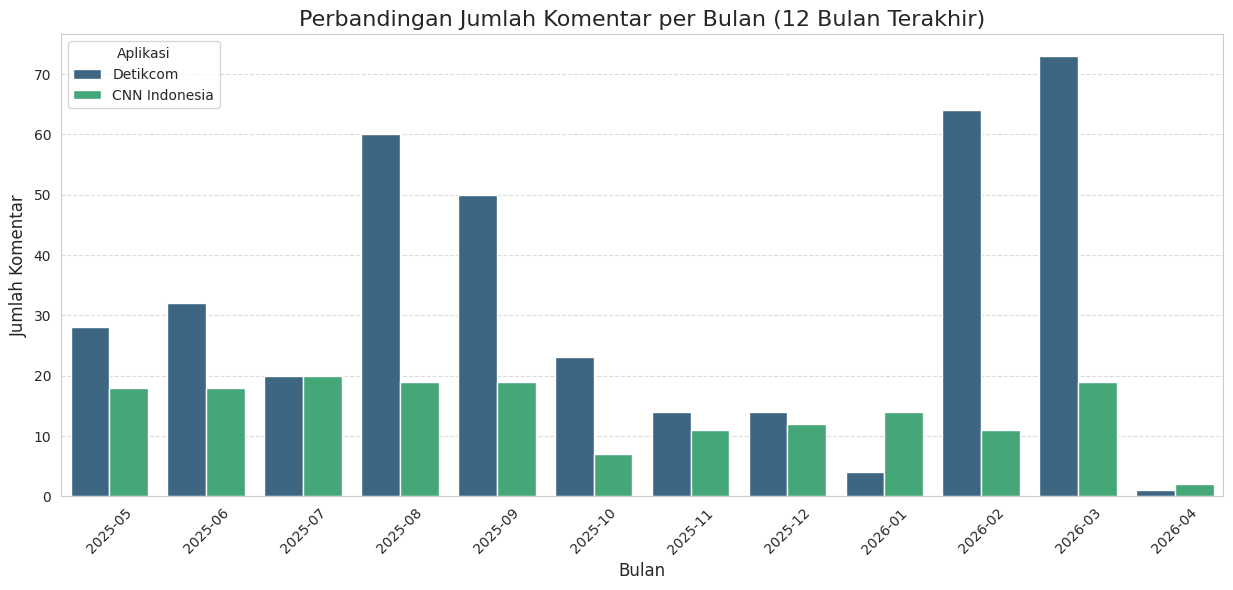

App,CNN Indonesia,Detikcom
Month_Year,,
2025-05,18,28
2025-06,18,32
2025-07,20,20
2025-08,19,60
2025-09,19,50
2025-10,7,23
2025-11,11,14
2025-12,12,14
2026-01,14,4


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load datasets
df_detik = pd.read_csv('Hasil_Preprocessing_Data_Detikcom.csv')
df_cnn = pd.read_csv('Hasil_Preprocessing_Data_CNN_Indonesia.csv')

# Convert 'Date' to datetime objects
df_detik['Date'] = pd.to_datetime(df_detik['Date'])
df_cnn['Date'] = pd.to_datetime(df_cnn['Date'])

# Helper function to get monthly counts for the last 12 months
def get_monthly_stats(df, label):
    # Extract Year-Month
    df['Month_Year'] = df['Date'].dt.to_period('M')
    # Group and count
    monthly_counts = df.groupby('Month_Year').size().reset_index(name='Count')
    monthly_counts['App'] = label
    # Take the last 12 available months
    return monthly_counts.sort_values('Month_Year').tail(12)

stats_detik = get_monthly_stats(df_detik, 'Detikcom')
stats_cnn = get_monthly_stats(df_cnn, 'CNN Indonesia')

# Combine for visualization
combined_stats = pd.concat([stats_detik, stats_cnn])
combined_stats['Month_Year'] = combined_stats['Month_Year'].astype(str)

# Visualization
plt.figure(figsize=(15, 6))
sns.barplot(data=combined_stats, x='Month_Year', y='Count', hue='App', palette='viridis')
plt.title('Perbandingan Jumlah Komentar per Bulan (12 Bulan Terakhir)', fontsize=16)
plt.xlabel('Bulan', fontsize=12)
plt.ylabel('Jumlah Komentar', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Aplikasi')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Display summary table
pivot_df = combined_stats.pivot(index='Month_Year', columns='App', values='Count').fillna(0)
display(pivot_df)